# Final Submission: Integrating Earth Observation Embeddings and Machine Learning for Maize Yield Prediction in Kenya

**DSA 8102 - Data Mining, Storage and Retrieval**  
**Student: Nturibi Gacheri Lydiah**

This project investigates a practical GeoAI question: **does adding environmental information, particularly learned Earth observation embeddings, improve maize yield prediction beyond fertilizer rates alone?**

The analysis combines long-term agronomic trial observations with climate, soil, topography and AlphaEarth satellite embeddings. It then compares several machine learning feature architectures using a common 80:20 train/test split.


# Notebook Structure and Rubric Alignment

The notebook follows the marking rubric and is organised around the seven specific objectives.

| Rubric requirement | Where it is addressed |
|---|---|
| Abstract | Abstract |
| Background | Introduction: Background |
| Research problem | Introduction: Research Problem |
| Objectives | Introduction: Objectives |
| Data description and variable table | Objective 1 |
| Data cleaning | Objectives 1 and 2 |
| Descriptive analytics | Objective 3 |
| Diagnostic analytics | Objective 3 |
| Pre-treatment for machine learning | Objectives 4 and 5 |
| Predictive data analytics | Objective 6 |
| Results and discussion | Objective 7 |
| Conclusion | Conclusion |
| Recommendations | Recommendations and Future Work |
| References | References and Data Sources |

The objective-based structure makes it clear how each analysis step answers the research questions and contributes to the final model comparison.


# Abstract

Maize yield response to fertilizer varies across Kenya because nutrient management interacts with climate, soil, topography and wider environmental conditions. This study evaluated whether learned Earth observation embeddings improve maize yield prediction beyond fertilizer rates and conventional environmental variables. Long Rain maize trial observations from KALRO, CIAT and IITA were cleaned, spatially validated and enriched with monthly climate variables, soil and topographic properties, and 64 AlphaEarth satellite embedding dimensions. The cleaned Long Rain analysis table contained **10,842 observations across 28 counties**, while the common AlphaEarth modelling subset contained **1,036 observations**, split into **828 training and 208 testing records**. Five regression algorithms were compared across seven feature architectures using the same 80:20 split. Fertilizer rates alone produced a test R² of **0.258**. The conventional N + P + soil + climate model improved test R² to **0.638**. The best-performing architecture was **N + P + AlphaEarth**, with **training R² = 0.684**, **testing R² = 0.682**, and **test RMSE = 1,282 kg/ha**. Full GeoAI integration also performed strongly with **test R² = 0.662**. The findings show that AlphaEarth embeddings contain useful environmental information that improves prediction when combined with agronomic fertilizer inputs.


# Introduction

## Background

Maize is Kenya's most widely consumed staple crop and is important for household food security, farm income and national agricultural planning. Fertilizer is one of the main management tools used to improve maize productivity, but the same fertilizer rate can produce very different yields across locations and seasons. Crop response is influenced by nitrogen and phosphorus application, rainfall, temperature, soil properties, terrain, crop timing and other environmental conditions. Agronomic trial datasets capture fertilizer treatments and observed yield well, but they may not fully describe the surrounding environment. Geospatial data can add climate, soil and topographic information to these observations. More recently, Earth observation embeddings such as AlphaEarth provide learned numerical representations of landscape conditions. This project combines these data sources to test whether environmental information improves machine learning prediction of maize yield.


## Research Problem

Fertilizer advisory systems need models that can account for both fertilizer application and the environmental conditions under which fertilizer is used. A model based only on N and P rates may not explain why similar treatments produce different yields across Kenya's diverse environments. Climate, soil and topographic variables can provide important environmental context, but they require several separate data layers and may still miss complex landscape patterns. Earth observation embeddings offer another approach by summarising satellite-observed environmental patterns into learned numerical features. Their value for agronomic prediction, however, must be tested using real trial observations. The main research problem is therefore to determine whether conventional geospatial variables and AlphaEarth embeddings improve maize yield prediction beyond fertilizer rates alone.


## Objectives

### General Objective

To evaluate whether integrating geospatial variables and Earth observation embeddings with agronomic maize trial data improves machine learning prediction of maize yield in Kenya.

### Specific Objectives

1. To clean and structure long-term Long Rain maize trial observations while preserving row-level yield and fertilizer treatments.
2. To validate trial coordinates against Kenya county boundaries and document spatial data-quality issues.
3. To conduct descriptive and diagnostic analysis of yield, fertilizer rates, temporal coverage and spatial distribution.
4. To extract and integrate climate, soil and topographic variables from geospatial data sources.
5. To integrate AlphaEarth satellite embeddings with agronomic trial observations available from 2017 onward.
6. To compare machine learning performance across fertilizer-only, conventional environmental, embedding-based and combined GeoAI feature architectures.
7. To quantify whether AlphaEarth embeddings provide additional predictive value beyond conventional agronomic and environmental predictors.


# Objective 1: Clean and Structure the Long Rain Maize Trial Data

## 1.1 Data Description

The primary dataset consists of long-term on-station maize trials assembled through collaboration between **KALRO, CIAT and IITA**. The trial database is an internal research dataset and is not currently an open-source resource. After cleaning, the Long Rain analysis table spans crop years **1969 to 2025** and contains treatment-level observations from **28 Kenyan counties**, although temporal coverage is much denser in the more recent decades. Each record represents a managed agronomic trial plot or treatment rather than farmer recall data. The core variables include observed maize yield, nitrogen (N), phosphorus (P) and potassium (K) fertilizer rates, crop season, planting and harvest dates, variety, treatment information, county and geographic coordinates. External environmental variables were added only after agronomic and spatial quality checks. Monthly climate information was derived from CHIRPS and ERA5-Land for supported trial years from **1997 to 2025**. Soil properties were extracted from SoilGrids and terrain variables from SRTM. AlphaEarth/Satellite Embedding features were available for **2017 to 2025** and contributed 64 learned embedding dimensions (`A00`-`A63`). Because AlphaEarth does not cover the full historical trial period, embedding comparisons were performed on a common modelling subset so that all feature architectures were evaluated using the same observations.

## Key variables used in the workflow

| Variable group | Main variables | Source | Role in the analysis |
|---|---|---|---|
| Target | `yield` | KALRO-CIAT-IITA trials | Maize yield to be predicted |
| Fertilizer | `n`, `p`, `k` | KALRO-CIAT-IITA trials | Agronomic treatment information |
| Crop timing | planting date, harvest date, `year` | Trial data | Crop-year definition and temporal matching |
| Location | longitude, latitude, county | Trial data + GADM validation | Spatial quality control and feature extraction |
| Rainfall | CHIRPS precipitation | Google Earth Engine | Seasonal rainfall context |
| Climate | temperature, solar radiation, humidity, wind, precipitation | ERA5-Land | Monthly climate context |
| Soil | pH, SOC, nitrogen, clay, sand, silt, CEC | SoilGrids | Soil fertility and texture context |
| Topography | elevation, slope, aspect | SRTM | Landscape context |
| Earth observation embeddings | `A00`-`A63` | AlphaEarth / Satellite Embedding | Learned landscape representation |


## 1.2 Methodological Approach

The agronomic trial record is kept as the main unit of analysis. Yield and fertilizer rates are not averaged across coordinate-year groups because this would remove treatment-level variation. Unique coordinate and coordinate-year tables are created only to reduce repeated geospatial extraction. The extracted environmental variables are then joined back to the original row-level trial records.

The broader cleaned Long Rain dataset is used for exploratory analysis and geospatial enrichment. A more focused NP subset is created for predictive modelling using `P < 40 kg/ha`, `300 < yield < 15,000 kg/ha`, and explicit `K = 0` observations. This creates a more consistent modelling population without treating K-positive records as invalid.

All feature architectures that include AlphaEarth are compared on the same common observations. This ensures that differences in model performance are caused by the predictors rather than by changes in sample composition.


## 1.3 Workflow Overview

The analysis follows these main steps:

1. Load and document the maize trial data.
2. Standardise variables and clean crop dates, fertilizer rates, yield and coordinates.
3. Validate coordinates against Kenya county boundaries.
4. Conduct descriptive, diagnostic and spatial exploratory analysis.
5. Create the Long Rain analysis dataset.
6. Extract climate, soil, topographic and AlphaEarth variables.
7. Merge the geospatial variables back to the original trial records.
8. Prepare a common modelling population.
9. Compare fertilizer-only, conventional environmental, embedding-based and Full GeoAI feature architectures.
10. Interpret whether AlphaEarth adds predictive value.


## 1.4 Load Libraries


In [1]:
# Install only if needed, then restart the kernel:
# %pip install pandas numpy openpyxl geopandas fiona shapely matplotlib plotly scikit-learn earthengine-api geemap

from pathlib import Path
import re
import unicodedata
import urllib.request
import json

import numpy as np
import pandas as pd

import geopandas as gpd
import fiona

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display, Markdown

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)

# Choose a Plotly renderer that works well in notebooks.
import plotly.io as pio
pio.renderers.default = "iframe_connected"

print("Libraries loaded.")
from IPython.display import Markdown, display

Libraries loaded.


**Explanation:** The required Python libraries loaded successfully. This confirms that the notebook environment is ready for data cleaning, GIS analysis, visualisation and machine learning.


In [2]:
# Plotly notebook display helper
def fit_plotly_window(fig, height=520, bottom_margin=110, legend=True):
    """Keep interactive Plotly figures and legends inside the notebook window."""
    fig.update_layout(
        autosize=True,
        width=None,
        height=height,
        margin=dict(l=65, r=35, t=80, b=bottom_margin),
        hoverlabel=dict(namelength=-1),
    )
    fig.update_xaxes(automargin=True)
    fig.update_yaxes(automargin=True)

    if legend:
        fig.update_layout(
            legend=dict(
                orientation="h",
                yanchor="top",
                y=-0.20,
                xanchor="center",
                x=0.5,
                title_text="",
            )
        )

    return fig

## 1.5 Project Paths and Parameters

The paths below use `data_raw`, `data_interim`, `data_processed` and `outputs` folders. Stable filenames are used so that the workflow can be rerun and the main outputs can be traced easily.


In [3]:
# If the notebook is inside a notebooks/ folder, use its parent as the project root.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()

DATA_RAW = PROJECT_DIR / "data_raw"
DATA_INTERIM = PROJECT_DIR / "data_interim"
DATA_PROCESSED = PROJECT_DIR / "data_processed"
OUTPUTS = PROJECT_DIR / "outputs"

# Existing CSV/HTML/PNG outputs with the same filenames will be overwritten when the notebook is re-run.
for folder in [
    DATA_RAW / "maize",
    DATA_RAW / "boundaries",
    DATA_INTERIM / "cleaned",
    DATA_INTERIM / "geoqa",
    DATA_INTERIM / "gee_exports",
    DATA_PROCESSED,
    OUTPUTS / "tables",
    OUTPUTS / "figures",
    OUTPUTS / "maps",
]:
    folder.mkdir(parents=True, exist_ok=True)

RAW_WORKBOOK = DATA_RAW / "maize" / "Combined_CGIAR_KALRO_06_Aug_version_03.xlsx"
SHEET_NAME = "Combined_CG_KALRO_Data"
GADM_GPKG = DATA_RAW / "boundaries" / "gadm41_KEN.gpkg"

# We're modelling the LR season first.
MAIN_SEASON = "Long Rain"

# Revised modelling threshold after comparison with the validated NP workflow.
# The earlier workflow used P < 50; the refined modelling handoff uses P < 40
# so that the Python population is closer to the AgWise benchmark. (Based on domain knowledge)
P_MAX_FOR_MODEL = 40

# Modelling-specific yield limits. These do not redefine agronomic reality;
# they remove values outside the previously agreed modelling population.
MODEL_YIELD_MIN = 300
MODEL_YIELD_MAX = 15000

# Plausible maize season length used only for date QA and date reconstruction. Based on domain expert knowledge.
MIN_SEASON_DAYS = 60
MAX_SEASON_DAYS = 240

# Dataset availability windows.
# CHIRPS starts in 1981. AlphaEarth/Satellite Embedding starts in 2017, but the final
# available year is checked dynamically after Earth Engine is initialized.
CLIMATE_MIN_YEAR = 1981
ALPHAEARTH_COLLECTION = "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"
ALPHAEARTH_MIN_YEAR = 2017

print("Project directory:", PROJECT_DIR)
print("Raw workbook:", RAW_WORKBOOK)
print("Main season:", MAIN_SEASON)
print("P filter: p <", P_MAX_FOR_MODEL)
print("AlphaEarth collection:", ALPHAEARTH_COLLECTION)

Project directory: C:\Users\L.Nturibi\OneDrive - CGIAR\IITA_CGIAR\IITA\2026\Strathmore\Research_Work\DMSR_Project
Raw workbook: C:\Users\L.Nturibi\OneDrive - CGIAR\IITA_CGIAR\IITA\2026\Strathmore\Research_Work\DMSR_Project\data_raw\maize\Combined_CGIAR_KALRO_06_Aug_version_03.xlsx
Main season: Long Rain
P filter: p < 40
AlphaEarth collection: GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL


**Explanation:** The project paths and main analysis settings are defined here. The analysis focuses on Long Rain, uses `P < 40 kg/ha` for the modelling population, and uses the annual AlphaEarth satellite embedding collection.


## 1.6 Load Raw Maize Trial Data

The combined maize workbook is loaded and checked before cleaning. The initial summary provides the number of observations, variables and basic data structure.


In [4]:
raw = pd.read_excel(RAW_WORKBOOK, sheet_name=SHEET_NAME)

print("Raw data shape:", raw.shape) # size of the df

raw_overview = pd.DataFrame({
    "metric": [
        "Raw rows", "Raw columns", "Unique IDs",
        "Rows with yield", "Rows with N", "Rows with P",
        "Rows with longitude", "Rows with latitude", "Rows with adm1",
        "Long Rain rows", "Short Rain rows"
    ],
    "value": [
        len(raw), raw.shape[1],
        raw["ID"].nunique() if "ID" in raw.columns else np.nan,
        raw["yield(kg/ha)"].notna().sum() if "yield(kg/ha)" in raw.columns else np.nan,
        raw["N_fertilizer(kg/ha)"].notna().sum() if "N_fertilizer(kg/ha)" in raw.columns else np.nan,
        raw["P_fertilizer(kg/ha)"].notna().sum() if "P_fertilizer(kg/ha)" in raw.columns else np.nan,
        raw["longitude"].notna().sum() if "longitude" in raw.columns else np.nan,
        raw["latitude"].notna().sum() if "latitude" in raw.columns else np.nan,
        raw["adm1"].notna().sum() if "adm1" in raw.columns else np.nan,
        raw["season"].astype(str).str.strip().eq("Long Rain").sum() if "season" in raw.columns else np.nan,
        raw["season"].astype(str).str.strip().eq("Short Rain").sum() if "season" in raw.columns else np.nan,
    ]
})

display(raw_overview)
raw_overview.to_csv(OUTPUTS / "tables" / "00_raw_data_overview.csv", index=False) # save

Raw data shape: (21114, 290)


,metric,value
0,Raw rows,21114
1,Raw columns,290
2,Unique IDs,21114
3,Rows with yield,20883
4,Rows with N,21069
5,Rows with P,21016
6,Rows with longitude,21114
7,Rows with latitude,21114
8,Rows with adm1,20175
9,Long Rain rows,15789


**Interpretation:** The raw dataset contains **21,114 observations and 290 variables**. It includes **15,789 Long Rain records** and **5,325 Short Rain records**. Coordinates are available for all records, while yield, N, P and county information have some missing values that require cleaning.


In [5]:
raw.head()

,ID,Institution_data_owner,dataset_id,record_id,date,reference,variable,method,LTE_name,trial_id,plot_id,crop,variety,variety_code,variety_type,season,planting_date,emergence_date,transplanting_date,heading_date,flowering_date,maturity_date,harvest_date,growth_stage,flooded,on_farm,is_survey,treatment,rep,intercrops,intercrop_type,previous_crop,crop_rotation,dmy_roots,dmy_stems,dmy_leaves,dmy_storage,dmy_total,dmy_residue,fwy_roots,fwy_stems,fwy_leaves,fwy_total,fwy_residue,yield_part,yield(kg/ha),yield_moisture,yield_isfresh,yield_marketable,grain_fill,seed_weight,fertilizer_used,fertilizer_type,fertilizer_date,fertilizer_dap,fertilizer_amount,treatment.1,N_fertilizer(kg/ha),N_splits,P_fertilizer(kg/ha),K_fertilizer(kg/ha),Zn_fertilizer,S_fertilizer,B_fertilizer,Ca_fertilizer,Mg_fertilizer,Fe_fertilizer,Mn_fertilizer,Cl_fertilizer,Cu_fertilizer,Mo_fertilizer,N_fixation,N_organic,P_organic,K_organic,Ca_organic,Mg_organic,lime_used,lime(kg/ha),gypsum,...,crop_price,fertilizer_price,currency,drought_stress,LAI,harvest_index,farmer_gender,virus_severity,shelling_percentage,CA_years,striga_trial,borer_trial,striga_infected,country,adm1,adm2,adm3,adm4,adm5,location,site,longitude,latitude,geo_uncertainty,geo_from_source,elevation,depth,depth_top,depth_bottom,soil_depth,soil_type,soil_pH,soil_pH_KCl,soil_pH_CaCl2,soil_sand,soil_clay,soil_silt,soil_texture,soil_sand_coarse,soil_sand_fine,soil_silt_coarse,soil_silt_fine,soil_SOM,soil_C_total (%),soil_SOC (mg/kg),soil_N,soil_N_total(mg/kg),soil_K,soil_K_exch(cmol(+)/kg),soil_P(mg/kg),soil_P_method,soil_P_total,soil_Ca (mg/kg),soil_Ca_exch,soil_Mg (mg/kg),soil_Mg_exch,soil_B (mg/kg),soil_Cu (mg/kg),soil_Mn (mg/kg),soil_Fe (mg/kg),soil_S,soil_Zn (mg/kg),soil_Na (mg/kg),soil_Al,soil_Al_exch (cmol(+)/kg),soil_EC,soil_bd (bulk density g/cm3),soil_CEC,soil_ECEC,soil_CEC.1,soil_color,soil_quality,landscape_position,soil_constraint,soil_ex_acidity (meq%),soil_Al_sat,soil_WHC_sat,soil_CO2,soil_N2O,soil_NO
0,37,KALRO,NaN,NaN,2025-12-11,NaN,NaN,NaN,Kajiado SR2015_SR2016 Maize,NaN,NaN,Maize,Duma 43,NaN,NaN,Short Rain,2015-10-22,2015-08-11,NaN,NaN,12/28/2015,2016-04-02 00:00:00,2016-03-09,NaN,NaN,NaN,NaN,T1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11888.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,T1,40.0,NaN,17.2,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.15,NaN,NaN,NaN,0.089744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,38,KALRO,NaN,NaN,2025-12-11,NaN,NaN,NaN,Kajiado SR2015_SR2016 Maize,NaN,NaN,Maize,Duma 43,NaN,NaN,Short Rain,2015-10-22,2015-08-11,NaN,NaN,12/28/2015,2016-04-02 00:00:00,2016-03-09,NaN,NaN,NaN,NaN,T3,1.0,Yes,Bean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4823.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,T3,40.0,NaN,17.2,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.15,NaN,NaN,NaN,0.089744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,39,KALRO,NaN,NaN,2025-12-11,NaN,NaN,NaN,Kajiado SR2015_SR2016 Maize,NaN,NaN,Maize,Duma 43,NaN,NaN,Short Rain,2015-10-22,2015-08-11,NaN,NaN,12/28/2015,2016-04-02 00:00:00,2016-03-09,NaN,NaN,NaN,NaN,T4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7487.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,T4,20.0,NaN,17.2,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kenya,Kajiado

**Explanation:** The first rows confirm that the raw data are stored at trial-treatment level. Important fields such as crop, season, dates, yield, fertilizer rates and location are present, although some fields contain missing values.


## 1.7 Select Core Variables

Only variables required for data cleaning, exploratory analysis, spatial validation, geospatial integration and predictive modelling are carried forward.


In [6]:
core_cols = [
    "ID", "Institution_data_owner", "dataset_id", "record_id", "year",
    "LTE_name",
    "crop", "variety", "season",
    "planting_date", "harvest_date", "emergence_date",
    "treatment", "yield(kg/ha)",
    "fertilizer_used", "fertilizer_type",
    "fertilizer_amount", "N_fertilizer(kg/ha)", "P_fertilizer(kg/ha)",
    "K_fertilizer(kg/ha)",
    "lime_used", "lime(kg/ha)", "OM_used", "OM_amount(kg/ha)",
    "inoculated", "intercrops", 
    "country", "adm1", "adm2", "adm3", "adm4", "adm5", "location", "site",
    "longitude", "latitude",
]

soil_cols = [
    "soil_depth", "soil_type", "soil_pH",
]

selected_cols = [c for c in core_cols + soil_cols if c in raw.columns]
maize = raw[selected_cols].copy() # our df

print("Selected data shape:", maize.shape)
display(pd.DataFrame({"selected_column": selected_cols}).head())

Selected data shape: (21114, 38)


,selected_column
0,ID
1,Institution_data_owner
2,dataset_id
3,record_id
4,LTE_name


**Explanation:** The dataset is reduced from 290 variables to **38 core variables** while keeping all **21,114 observations**. These variables contain the information needed for cleaning, spatial validation, exploratory analysis and modelling.


In [7]:
# view the actual 
maize.head()

,ID,Institution_data_owner,dataset_id,record_id,LTE_name,crop,variety,season,planting_date,harvest_date,emergence_date,treatment,yield(kg/ha),fertilizer_used,fertilizer_type,fertilizer_amount,N_fertilizer(kg/ha),P_fertilizer(kg/ha),K_fertilizer(kg/ha),lime_used,lime(kg/ha),OM_used,OM_amount(kg/ha),inoculated,intercrops,country,adm1,adm2,adm3,adm4,adm5,location,site,longitude,latitude,soil_depth,soil_type,soil_pH
0,37,KALRO,NaN,NaN,Kajiado SR2015_SR2016 Maize,Maize,Duma 43,Short Rain,2015-10-22,2016-03-09,2015-08-11,T1,11888.0,NaN,NaN,NaN,40.0,17.2,0.0,No,NaN,NaN,NaN,NaN,NaN,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN
1,38,KALRO,NaN,NaN,Kajiado SR2015_SR2016 Maize,Maize,Duma 43,Short Rain,2015-10-22,2016-03-09,2015-08-11,T3,4823.0,NaN,NaN,NaN,40.0,17.2,0.0,No,NaN,NaN,NaN,NaN,Yes,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN
2,39,KALRO,NaN,NaN,Kajiado SR2015_SR2016 Maize,Maize,Duma 43,Short Rain,2015-10-22,2016-03-09,2015-08-11,T4,7487.0,NaN,NaN,NaN,20.0,17.2,0.0,No,NaN,NaN,NaN,NaN,NaN,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN
3,40,KALRO,NaN,NaN,Kajiado SR2015_SR2016 Maize,Maize,Duma 43,Short Rain,2015-10-22,2016-03-09,2015-08-11,T6,7472.0,NaN,NaN,NaN,20.0,17.2,0.0,No,NaN,NaN,NaN,NaN,Yes,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN
4,41,KALRO,NaN,NaN,Kajiado SR2015_SR2016 Maize,Maize,Duma 43,Short Rain,2015-10-22,2016-03-09,2015-08-11,T4,6648.0,NaN,NaN,NaN,20.0,17.2,0.0,No,NaN,NaN,NaN,NaN,NaN,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN


**Explanation:** The selected dataset still preserves the original treatment-level structure. Each row contains the agronomic and location information needed for the later cleaning and modelling steps.


## 1.8 Data Cleaning: Standardise Variable Names and Formats

Key variables are converted into consistent Python-friendly formats. Yield and fertilizer rates are converted to numeric values, crop dates are parsed, crop and season labels are cleaned, and a unique row identifier is created. The row identifier is retained throughout the workflow to confirm that feature merging does not collapse the original trial observations.


In [8]:
def to_numeric_clean(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan, "NA": np.nan, "#VALUE!": np.nan}),
        errors="coerce"
    )

def clean_text(series):
    return (
        series.astype(str)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan, "NA": np.nan})
    )

def parse_date_clean(series):
    s = series.copy()
    parsed = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")

    numeric = pd.to_numeric(s, errors="coerce")
    excel_serial_mask = numeric.between(20000, 60000)

    parsed.loc[excel_serial_mask] = pd.to_datetime(
        numeric.loc[excel_serial_mask],
        unit="D",
        origin="1899-12-30",
        errors="coerce"
    )

    remaining = parsed.isna()
    parsed.loc[remaining] = pd.to_datetime(s.loc[remaining], errors="coerce", dayfirst=True)

    remaining = parsed.isna()
    parsed.loc[remaining] = pd.to_datetime(s.loc[remaining], errors="coerce", dayfirst=False)

    return parsed

def normalise_county_name(value):
    if pd.isna(value):
        return ""

    value = str(value).strip()
    value = unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("utf-8")
    value = value.lower().replace("county", "")
    value = re.sub(r"[^a-z0-9]+", "", value)

    aliases = {
        "transnzoia": "transnzoia",
        "elgeyomarakwet": "elgeyomarakwet",
        "tharakanithi": "tharakanithi",
        "muranga": "muranga",
        "homabay": "homabay",
        "homaabay": "homabay",
        "uasingishu": "uasingishu",
        "taitataveta": "taitataveta",
    }
    return aliases.get(value, value)

maize["yield"] = to_numeric_clean(maize["yield(kg/ha)"])
maize["n"] = to_numeric_clean(maize["N_fertilizer(kg/ha)"])
maize["p"] = to_numeric_clean(maize["P_fertilizer(kg/ha)"])
maize["k"] = to_numeric_clean(maize["K_fertilizer(kg/ha)"])

maize["long2_raw"] = to_numeric_clean(maize["longitude"])
maize["lat2_raw"] = to_numeric_clean(maize["latitude"])

maize["crop_clean"] = clean_text(maize["crop"]).str.lower()
maize["season_clean"] = clean_text(maize["season"])
maize["adm1_original"] = clean_text(maize["adm1"])
maize["adm1_original_norm"] = maize["adm1_original"].apply(normalise_county_name)

maize["record_date"] = parse_date_clean(maize["date"]) if "date" in maize.columns else pd.NaT
maize["Planting_date_raw"] = parse_date_clean(maize["planting_date"])
maize["Harvest_date_raw"] = parse_date_clean(maize["harvest_date"])
maize["Emergence_date_raw"] = parse_date_clean(maize["emergence_date"])

maize["unique_row_id"] = np.arange(1, len(maize) + 1)

print("Standardised variables created: yield, n, p, k, cleaned coordinates, crop/season labels and parsed crop dates.")
maize.head()

Standardised variables created: yield, n, p, k, cleaned coordinates, crop/season labels and parsed crop dates.


,ID,Institution_data_owner,dataset_id,record_id,LTE_name,crop,variety,season,planting_date,harvest_date,emergence_date,treatment,yield(kg/ha),fertilizer_used,fertilizer_type,fertilizer_amount,N_fertilizer(kg/ha),P_fertilizer(kg/ha),K_fertilizer(kg/ha),lime_used,lime(kg/ha),OM_used,OM_amount(kg/ha),inoculated,intercrops,country,adm1,adm2,adm3,adm4,adm5,location,site,longitude,latitude,soil_depth,soil_type,soil_pH,yield,n,p,k,long2_raw,lat2_raw,crop_clean,season_clean,adm1_original,adm1_original_norm,record_date,Planting_date_raw,Harvest_date_raw,Emergence_date_raw,unique_row_id
0,37,KALRO,NaN,NaN,Kajiado SR2015_SR2016 Maize,Maize,Duma 43,Short Rain,2015-10-22,2016-03-09,2015-08-11,T1,11888.0,NaN,NaN,NaN,40.0,17.2,0.0,No,NaN,NaN,NaN,NaN,NaN,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN,11888.0,40.0,17.2,0.0,36.919722,-1.951389,maize,Short Rain,Kajiado,kajiado,NaT,2015-10-22,2016-03-09,2015-08-11,1
1,38,KALRO,NaN,NaN,Kajiado SR2015_SR2016 Maize,Maize,Duma 43,Short Rain,2015-10-22,2016-03-09,2015-08-11,T3,4823.0,NaN,NaN,NaN,40.0,17.2,0.0,No,NaN,NaN,NaN,NaN,Yes,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN,4823.0,40.0,17.2,0.0,36.919722,-1.951389,maize,Short Rain,Kajiado,kajiado,NaT,2015-10-22,2016-03-09,2015-08-11,2
2,39,KALRO,NaN,NaN,Kajiado SR2015_SR2016 Maize,Maize,Duma 43,Short Rain,2015-10-22,2016-03-09,2015-08-11,T4,7487.0,NaN,NaN,NaN,20.0,17.2,0.0,No,NaN,NaN,NaN,NaN,NaN,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN,7487.0,20.0,17.2,0.0,36.919722,-1.951389,maize,Short Rain,Kajiado,kajiado,NaT,2015-10-22,2016-03-09,2015-08-11,3
3,40,KALRO,NaN,NaN,Kajiado SR2015_SR2016 Maize,Maize,Duma 43,Short Rain,2015-10-22,2016-03-09,2015-08-11,T6,7472.0,NaN,NaN,NaN,20.0,17.2,0.0,No,NaN,NaN,NaN,NaN,Yes,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN,7472.0,20.0,17.2,0.0,36.919722,-1.951389,maize,Short Rain,Kajiado,kajiado,NaT,2015-10-22,2016-03-09,2015-08-11,4
4,41,KALRO,NaN,NaN,Kajiado SR2015_SR2016 Maize,Maize,Duma 43,Short Rain,2015-10-22,2016-03-09,2015-08-11,T4,6648.0,NaN,NaN,NaN,20.0,17.2,0.0,No,NaN,NaN,NaN,NaN,NaN,Kenya,Kajiado,NaN,NaN,NaN,NaN,NaN,Kajiado County,36.919722,-1.951389,NaN,NaN,NaN,6648.0,20.0,17.2,0.0,36.919722,-1.951389,maize,Short Rain,Kajiado,kajiado,NaT,2015-10-22,2016-03-09,2015-08-11,5


**Explanation:** The main modelling variables have been standardised successfully. Yield, N, P, K and coordinates are numeric, while crop, season and date fields are stored in consistent formats for later analysis.


## 1.9 Data Cleaning: Crop Dates

The general `date` field is treated as an audit date rather than a crop date. Crop year is derived from planting and harvest dates. If one crop date is missing, it is reconstructed using the observed median crop duration for the relevant season. Records where both planting and harvest dates are missing are excluded from modelling because a reliable crop year cannot be assigned.


In [9]:
maize["observed_duration_days"] = (maize["Harvest_date_raw"] - maize["Planting_date_raw"]).dt.days

maize["has_planting_date"] = maize["Planting_date_raw"].notna()
maize["has_harvest_date"] = maize["Harvest_date_raw"].notna()
maize["has_both_crop_dates"] = maize["has_planting_date"] & maize["has_harvest_date"]
maize["duration_plausible"] = maize["observed_duration_days"].between(MIN_SEASON_DAYS, MAX_SEASON_DAYS)

duration_reference_source = maize[
    maize["has_both_crop_dates"] &
    maize["duration_plausible"] &
    maize["season_clean"].notna()
].copy()

season_duration_reference = (
    duration_reference_source
    .groupby("season_clean", as_index=False)
    .agg(
        median_duration_days=("observed_duration_days", "median"),
        n_reference_rows=("observed_duration_days", "count")
    )
)

overall_duration_reference = int(round(duration_reference_source["observed_duration_days"].median()))
duration_lookup = dict(zip(
    season_duration_reference["season_clean"],
    season_duration_reference["median_duration_days"].round().astype(int)
))

def get_duration_reference(season):
    return int(duration_lookup.get(season, overall_duration_reference))

maize["duration_reference_days"] = maize["season_clean"].apply(get_duration_reference)

maize["Planting_date_final"] = pd.NaT
maize["Harvest_date_final"] = pd.NaT
maize["date_status"] = "unassigned"

# Keep complete, plausible observed crop dates.
mask_complete_valid = maize["has_both_crop_dates"] & maize["duration_plausible"]
maize.loc[mask_complete_valid, "Planting_date_final"] = maize.loc[mask_complete_valid, "Planting_date_raw"]
maize.loc[mask_complete_valid, "Harvest_date_final"] = maize.loc[mask_complete_valid, "Harvest_date_raw"]
maize.loc[mask_complete_valid, "date_status"] = "complete_observed_dates"

# Reconstruct missing planting date from observed harvest date.
mask_impute_planting = ~maize["has_planting_date"] & maize["has_harvest_date"]
maize.loc[mask_impute_planting, "Harvest_date_final"] = maize.loc[mask_impute_planting, "Harvest_date_raw"]
maize.loc[mask_impute_planting, "Planting_date_final"] = (
    maize.loc[mask_impute_planting, "Harvest_date_raw"] -
    pd.to_timedelta(maize.loc[mask_impute_planting, "duration_reference_days"], unit="D")
)
maize.loc[mask_impute_planting, "date_status"] = "planting_imputed_from_harvest"

# Reconstruct missing harvest date from observed planting date.
mask_impute_harvest = maize["has_planting_date"] & ~maize["has_harvest_date"]
maize.loc[mask_impute_harvest, "Planting_date_final"] = maize.loc[mask_impute_harvest, "Planting_date_raw"]
maize.loc[mask_impute_harvest, "Harvest_date_final"] = (
    maize.loc[mask_impute_harvest, "Planting_date_raw"] +
    pd.to_timedelta(maize.loc[mask_impute_harvest, "duration_reference_days"], unit="D")
)
maize.loc[mask_impute_harvest, "date_status"] = "harvest_imputed_from_planting"

# Rows where neither crop date is available cannot be assigned a defensible crop year.
mask_both_missing = ~maize["has_planting_date"] & ~maize["has_harvest_date"]
maize.loc[mask_both_missing, "date_status"] = "drop_missing_both_planting_and_harvest"

# Rows with both dates but implausible duration are flagged for review.
mask_invalid_duration = maize["has_both_crop_dates"] & ~maize["duration_plausible"]
maize.loc[mask_invalid_duration, "date_status"] = "review_implausible_observed_duration"

maize["model_duration_days"] = (maize["Harvest_date_final"] - maize["Planting_date_final"]).dt.days
maize["year"] = maize["Planting_date_final"].dt.year.astype("Int64")

display(season_duration_reference)
print("Overall median duration fallback:", overall_duration_reference)

date_summary = (
    maize.groupby(["season_clean", "date_status"], dropna=False)
    .size()
    .reset_index(name="records")
    .sort_values(["season_clean", "records"], ascending=[True, False])
)

display(date_summary)

season_duration_reference.to_csv(OUTPUTS / "tables" / "01_observed_season_length_reference.csv", index=False)
date_summary.to_csv(OUTPUTS / "tables" / "02_date_cleaning_summary.csv", index=False)

,season_clean,median_duration_days,n_reference_rows
0,Long Rain,154.0,13868
1,Short Rain,123.0,5325


Overall median duration fallback: 139


,season_clean,date_status,records
0,Long Rain,complete_observed_dates,13868
1,Long Rain,drop_missing_both_planting_and_harvest,929
3,Long Rain,planting_imputed_from_harvest,641
4,Long Rain,review_implausible_observed_duration,316
2,Long Rain,harvest_imputed_from_planting,35
5,Short Rain,complete_observed_dates,5325


**Interpretation:** Long Rain trials have a median observed crop duration of **154 days**, compared with **123 days** for Short Rain. Most Long Rain records have complete crop dates, but some require date reconstruction or review. Only records with defensible crop timing are carried into the modelling workflow.


In [10]:
date_review = maize[
    maize["date_status"].isin([
        "drop_missing_both_planting_and_harvest",
        "review_implausible_observed_duration"
    ])
][[
    "unique_row_id", "ID", "season_clean", "adm1_original",
    "record_date", "Planting_date_raw", "Harvest_date_raw",
    "observed_duration_days", "date_status",
    "yield", "n", "p", "long2_raw", "lat2_raw"
]].copy()

print("Rows requiring date review or dropping from modelling/GEE:", len(date_review))
print("Rows exported for date review:", len(date_review))

date_review.to_csv(DATA_INTERIM / "cleaned" / "date_review_or_dropped_rows.csv", index=False)

Rows requiring date review or dropping from modelling/GEE: 1245
Rows exported for date review: 1245


**Interpretation:** A total of **1,245 records** require date review or exclusion because both crop dates are missing or the observed crop duration is implausible. These records are exported separately so that the date-cleaning decisions remain transparent.


## 1.10 Data Cleaning: Agronomic Variables

Records that cannot support yield modelling are removed. These include non-maize records, missing or non-positive yield, missing N or P rates, and missing coordinates. Low yield values are reviewed carefully rather than removed automatically because they may represent genuine crop failure or poor treatment response.


In [11]:
maize["flag_non_maize"] = ~maize["crop_clean"].str.contains("maize", na=False)
maize["flag_bad_yield"] = maize["yield"].isna() | (maize["yield"] <= 100) # set a 100 kg/ha threshold
maize["flag_missing_n"] = maize["n"].isna()
maize["flag_missing_p"] = maize["p"].isna()
maize["flag_missing_coordinates"] = maize["long2_raw"].isna() | maize["lat2_raw"].isna()

basic_clean = maize[
    ~maize["flag_non_maize"] &
    ~maize["flag_bad_yield"] &
    ~maize["flag_missing_n"] &
    ~maize["flag_missing_p"] &
    ~maize["flag_missing_coordinates"]
].copy()

basic_removed = maize.loc[~maize.index.isin(basic_clean.index)].copy()

basic_cleaning_summary = pd.DataFrame({
    "cleaning_step": [
        "Selected rows",
        "Removed non-maize",
        "Removed missing/non-positive yield/low yields",
        "Removed missing N",
        "Removed missing P",
        "Removed missing coordinates",
        "Rows after basic agronomic cleaning"
    ],
    "records": [
        len(maize),
        int(maize["flag_non_maize"].sum()),
        int(maize["flag_bad_yield"].sum()),
        int(maize["flag_missing_n"].sum()),
        int(maize["flag_missing_p"].sum()),
        int(maize["flag_missing_coordinates"].sum()),
        len(basic_clean)
    ]
})

display(basic_cleaning_summary)
basic_cleaning_summary.to_csv(OUTPUTS / "tables" / "03_basic_agronomic_cleaning_summary.csv", index=False)
basic_removed.to_csv(DATA_INTERIM / "cleaned" / "basic_removed_rows.csv", index=False)

,cleaning_step,records
0,Selected rows,21114
1,Removed non-maize,0
2,Removed missing/non-positive yield/low yields,763
3,Removed missing N,45
4,Removed missing P,98
5,Removed missing coordinates,0
6,Rows after basic agronomic cleaning,20234


**Interpretation:** Basic agronomic cleaning reduces the dataset from **21,114 to 20,234 observations**. The largest reduction comes from missing, non-positive or very low yield values. A smaller number of records are removed because N or P is missing.


# Objective 2: Validate Trial Coordinates and Document Spatial Data Quality

## 2.1 Spatial QA and Coordinate Validation

Trial coordinates are checked against Kenya county boundaries from GADM. Reported county names are harmonised and compared with the county identified through a spatial join. Common coordinate errors are tested, including flipped latitude, flipped longitude and swapped longitude/latitude. A correction is accepted only when it improves the spatial match. Records that cannot be resolved with confidence are quarantined rather than used for geospatial extraction.

This step is important because incorrect coordinates would attach climate, soil or satellite information from the wrong location to a trial record.


In [12]:
if not GADM_GPKG.exists():
    gadm_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_KEN.gpkg"
    urllib.request.urlretrieve(gadm_url, GADM_GPKG)

layers = fiona.listlayers(GADM_GPKG)
print("Available GADM layers:", layers)

adm1_layer = [layer for layer in layers if layer.endswith("_1")][0]

kenya_adm1 = gpd.read_file(GADM_GPKG, layer=adm1_layer).to_crs("EPSG:4326")
kenya_adm1 = kenya_adm1[["NAME_1", "geometry"]].rename(columns={"NAME_1": "adm1_gadm"})
kenya_adm1["adm1_gadm_norm"] = kenya_adm1["adm1_gadm"].apply(normalise_county_name)

print(f"Loaded {len(kenya_adm1)} Kenya county boundaries from GADM.")

Available GADM layers: ['ADM_ADM_0', 'ADM_ADM_1', 'ADM_ADM_2', 'ADM_ADM_3']
Loaded 47 Kenya county boundaries from GADM.


**Explanation:** The GADM dataset successfully provides all **47 Kenya county boundaries**. These boundaries are used as the reference layer for checking whether trial coordinates fall in the reported county.


In [13]:
reported_counties = (
    basic_clean[["adm1_original", "adm1_original_norm"]]
    .drop_duplicates()
    .sort_values("adm1_original")
)

gadm_counties = (
    kenya_adm1[["adm1_gadm", "adm1_gadm_norm"]]
    .drop_duplicates()
    .sort_values("adm1_gadm")
)

county_name_audit = reported_counties.merge(
    gadm_counties,
    left_on="adm1_original_norm",
    right_on="adm1_gadm_norm",
    how="left"
)

display(county_name_audit.head(10))
county_name_audit.to_csv(OUTPUTS / "tables" / "04_county_name_harmonisation_audit.csv", index=False)

,adm1_original,adm1_original_norm,adm1_gadm,adm1_gadm_norm
0,Bungoma,bungoma,Bungoma,bungoma
1,Busia,busia,Busia,busia
2,Elgeyo-Marakwet,elgeyomarakwet,Elgeyo-Marakwet,elgeyomarakwet
3,Embu,embu,Embu,embu
4,Homabay,homabay,Homa Bay,homabay
5,Kajiado,kajiado,Kajiado,kajiado
6,Kakamega,kakamega,Kakamega,kakamega
7,Kiambu,kiambu,Kiambu,kiambu
8,Kilifi,kilifi,Kilifi,kilifi
9,Kirinyaga,kirinyaga,Kirinyaga,kirinyaga


**Interpretation:** The county-name audit confirms that reported county names can be matched to the GADM boundaries after text standardisation. This also resolves naming differences such as `Homabay` and `Homa Bay` before the spatial checks are performed.


In [14]:
KENYA_LON_MIN, KENYA_LON_MAX = 33, 42 # bound thresholds
KENYA_LAT_MIN, KENYA_LAT_MAX = -5, 6

def spatial_join_candidate(df, lon_values, lat_values, label):
    candidate = df[["unique_row_id", "ID", "adm1_original", "adm1_original_norm"]].copy()
    candidate[f"{label}_lon"] = lon_values
    candidate[f"{label}_lat"] = lat_values

    candidate[f"{label}_rough_bbox_ok"] = (
        candidate[f"{label}_lon"].between(KENYA_LON_MIN, KENYA_LON_MAX) &
        candidate[f"{label}_lat"].between(KENYA_LAT_MIN, KENYA_LAT_MAX)
    )

    candidate_gdf = gpd.GeoDataFrame(
        candidate,
        geometry=gpd.points_from_xy(candidate[f"{label}_lon"], candidate[f"{label}_lat"]),
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        candidate_gdf,
        kenya_adm1[["adm1_gadm", "adm1_gadm_norm", "geometry"]],
        how="left",
        predicate="intersects"
    )

    joined = joined.drop(columns=["geometry", "index_right"], errors="ignore")
    joined = joined.rename(columns={
        "adm1_gadm": f"{label}_adm1_gadm",
        "adm1_gadm_norm": f"{label}_adm1_gadm_norm"
    })
    joined[f"{label}_inside_kenya"] = joined[f"{label}_adm1_gadm"].notna()

    return joined[[
        "unique_row_id", f"{label}_lon", f"{label}_lat", f"{label}_rough_bbox_ok",
        f"{label}_adm1_gadm", f"{label}_adm1_gadm_norm", f"{label}_inside_kenya"
    ]]

coord_qa = basic_clean.copy()

candidates = [
    ("original", coord_qa["long2_raw"], coord_qa["lat2_raw"]),
    ("flip_lat", coord_qa["long2_raw"], -coord_qa["lat2_raw"]),
    ("flip_lon", -coord_qa["long2_raw"], coord_qa["lat2_raw"]),
    ("swap_xy", coord_qa["lat2_raw"], coord_qa["long2_raw"]),
    ("swap_xy_flip_lat", coord_qa["lat2_raw"], -coord_qa["long2_raw"]),
]

for label, lon_vals, lat_vals in candidates:
    joined = spatial_join_candidate(coord_qa, lon_vals, lat_vals, label)
    coord_qa = coord_qa.merge(joined, on="unique_row_id", how="left")

print("Coordinate candidate checks completed for original, flipped and swapped coordinate options.")

Coordinate candidate checks completed for original, flipped and swapped coordinate options.


**Explanation:** The notebook tests the original coordinates and common coordinate-error patterns, including sign changes and swapped longitude and latitude. These candidate checks are used to determine whether an incorrect coordinate can be corrected confidently.


In [15]:
def choose_coordinate(row):
    reported_norm = row["adm1_original_norm"]
    reported_missing = reported_norm == ""

    candidate_list = [
        ("original", row["original_lon"], row["original_lat"], row["original_adm1_gadm"], row["original_adm1_gadm_norm"], row["original_inside_kenya"]),
        ("flip_lat", row["flip_lat_lon"], row["flip_lat_lat"], row["flip_lat_adm1_gadm"], row["flip_lat_adm1_gadm_norm"], row["flip_lat_inside_kenya"]),
        ("flip_lon", row["flip_lon_lon"], row["flip_lon_lat"], row["flip_lon_adm1_gadm"], row["flip_lon_adm1_gadm_norm"], row["flip_lon_inside_kenya"]),
        ("swap_xy", row["swap_xy_lon"], row["swap_xy_lat"], row["swap_xy_adm1_gadm"], row["swap_xy_adm1_gadm_norm"], row["swap_xy_inside_kenya"]),
        ("swap_xy_flip_lat", row["swap_xy_flip_lat_lon"], row["swap_xy_flip_lat_lat"], row["swap_xy_flip_lat_adm1_gadm"], row["swap_xy_flip_lat_adm1_gadm_norm"], row["swap_xy_flip_lat_inside_kenya"]),
    ]

    # If reported county exists, accept only a candidate that lands in that county.
    if not reported_missing:
        for action, lon, lat, county, county_norm, inside in candidate_list:
            if bool(inside) and county_norm == reported_norm:
                return pd.Series({
                    "long2": lon, "lat2": lat, "county": county,
                    "coord_action": action,
                    "coord_status": "accepted_county_match",
                    "coord_review_flag": False
                })

        # If original is inside Kenya but not the reported county, quarantine for review.
        if bool(candidate_list[0][5]):
            return pd.Series({
                "long2": candidate_list[0][1], "lat2": candidate_list[0][2],
                "county": candidate_list[0][3],
                "coord_action": "original_inside_wrong_county",
                "coord_status": "quarantine_county_mismatch",
                "coord_review_flag": True
            })

        return pd.Series({
            "long2": np.nan, "lat2": np.nan, "county": np.nan,
            "coord_action": "no_candidate_matched_reported_county",
            "coord_status": "quarantine_no_valid_county_match",
            "coord_review_flag": True
        })

    # If reported county is missing, accept the first candidate that falls inside Kenya.
    for action, lon, lat, county, county_norm, inside in candidate_list:
        if bool(inside):
            return pd.Series({
                "long2": lon, "lat2": lat, "county": county,
                "coord_action": f"{action}_filled_missing_county",
                "coord_status": "accepted_missing_county_filled_spatially",
                "coord_review_flag": False
            })

    return pd.Series({
        "long2": np.nan, "lat2": np.nan, "county": np.nan,
        "coord_action": "outside_kenya_all_candidates",
        "coord_status": "quarantine_outside_kenya",
        "coord_review_flag": True
    })

chosen = coord_qa.apply(choose_coordinate, axis=1)
coord_qa = pd.concat([coord_qa, chosen], axis=1)

coord_qa["adm1_was_missing"] = coord_qa["adm1_original_norm"].eq("")
coord_qa["adm1_filled_spatially"] = coord_qa["adm1_was_missing"] & coord_qa["county"].notna()

coordinate_summary = (
    coord_qa.groupby(["coord_status", "coord_action"], dropna=False)
    .size()
    .reset_index(name="records")
    .sort_values("records", ascending=False)
)

display(coordinate_summary)
coordinate_summary.to_csv(OUTPUTS / "tables" / "05_coordinate_qa_summary.csv", index=False)

,coord_status,coord_action,records
1,accepted_county_match,original,17337
3,quarantine_county_mismatch,original_inside_wrong_county,1810
2,accepted_missing_county_filled_spatially,original_filled_missing_county,933
0,accepted_county_match,flip_lat,127
4,quarantine_no_valid_county_match,no_candidate_matched_reported_county,27


**Interpretation:** Most records, **17,337**, already match the reported county using the original coordinates. Another **933 records** have missing county labels that can be filled from the spatial location. The checks also identify **127 records** that can be corrected by flipping latitude, while unresolved county mismatches are kept for quarantine.


In [16]:
coordinate_corrections = coord_qa[
    coord_qa["coord_action"].isin(["flip_lat", "flip_lon", "swap_xy", "swap_xy_flip_lat"])
][[
    "unique_row_id", "ID", "adm1_original", "county",
    "long2_raw", "lat2_raw", "long2", "lat2",
    "original_adm1_gadm", "flip_lat_adm1_gadm",
    "flip_lon_adm1_gadm", "swap_xy_adm1_gadm",
    "coord_action", "coord_status",
    "yield", "n", "p", "season_clean"
]].copy()

quarantined_coordinates = coord_qa[
    coord_qa["coord_review_flag"]
][[
    "unique_row_id", "ID", "adm1_original",
    "long2_raw", "lat2_raw",
    "original_adm1_gadm", "flip_lat_adm1_gadm",
    "flip_lon_adm1_gadm", "swap_xy_adm1_gadm",
    "coord_action", "coord_status",
    "yield", "n", "p", "season_clean"
]].copy()

print("Accepted coordinate corrections:", len(coordinate_corrections))
print("Quarantined coordinate rows:", len(quarantined_coordinates))

display(coordinate_corrections.head(10))
display(quarantined_coordinates.head(10))

coordinate_corrections.to_csv(DATA_INTERIM / "geoqa" / "accepted_coordinate_corrections.csv", index=False)
quarantined_coordinates.to_csv(DATA_INTERIM / "geoqa" / "quarantined_coordinate_rows.csv", index=False)

Accepted coordinate corrections: 127
Quarantined coordinate rows: 1837


,unique_row_id,ID,adm1_original,county,long2_raw,lat2_raw,long2,lat2,original_adm1_gadm,flip_lat_adm1_gadm,flip_lon_adm1_gadm,swap_xy_adm1_gadm,coord_action,coord_status,yield,n,p,season_clean
2618,2813,4144,Kisii,Kisii,34.584444,-1.022500,34.858463,-0.802954,Migori,Kisii,NaN,NaN,flip_lat,accepted_county_match,424.0000,0.00,0.000,Short Rain
6608,7015,9264,Uasin Gishu,Uasin Gishu,35.147656,0.745267,35.505730,0.090070,Bungoma,Uasin Gishu,NaN,NaN,flip_lat,accepted_county_match,4747.6298,0.00,0.000,Long Rain
6609,7016,9265,Uasin Gishu,Uasin Gishu,35.147656,0.745267,35.505730,0.090070,Bungoma,Uasin Gishu,NaN,NaN,flip_lat,accepted_county_match,8088.3338,79.00,29.877,Long Rain
6610,7017,9266,Uasin Gishu,Uasin Gishu,35.147656,0.745267,35.505730,0.090070,Bungoma,Uasin Gishu,NaN,NaN,flip_lat,accepted_county_match,5341.9592,80.35,25.014,Long Rain
6611,7018,9267,Uasin Gishu,Uasin Gishu,35.147656,0.745267,35.513260,0.094520,Bungoma,Uasin Gishu,NaN,NaN,flip_lat,accepted_county_match,5494.6722,80.50,25.780,Long Rain
6612,7019,9268,Uasin Gishu,Uasin Gishu,35.147656,0.745267,35.513260,0.094520,Bungoma,Uasin Gishu,NaN,NaN,flip_lat,accepted_county_match,5852.2028,52.00,25.780,Long Rain
16369,17042,26881,Kisumu,Kisumu,34.395200,0.144210,34.964700,-0.343340,Siaya,Kisumu,NaN,NaN,flip_lat,accepted_county_match,1312.0000,100.00,30.000,Long Rain
16370,17043,26882,Kisumu,Kisumu,34.392600,0.163540,34.964700,-0.343340,Siaya,Kisumu,NaN,NaN,flip_lat,accepted_county_match,1808.0000,100.00,30.000,Long Rain
16371,17044,26883,Kisumu,Kisumu,34.420100,0.094820,34.964700,-0.343340,Siaya,Kisumu,NaN,NaN,flip_lat,accepted_county_match,3960.0000,100.00,30.000,Long Rain
16372,17045,26884,Kisumu,Kisumu,34.415700,0.096830,34.964700,-0.343340,Siaya,Kisumu,NaN,NaN,flip_lat,accepted_county_match,2077.0000,100.00,30.000,Long Rain


,unique_row_id,ID,adm1_original,long2_raw,lat2_raw,original_adm1_gadm,flip_lat_adm1_gadm,flip_lon_adm1_gadm,swap_xy_adm1_gadm,coord_action,coord_status,yield,n,p,season_clean
236,237,504,Kitui,35.016684,0.979931,Trans Nzoia,Narok,NaN,NaN,original_inside_wrong_county,quarantine_county_mismatch,7954.0,40.0,17.6,Long Rain
237,238,505,Kitui,35.016684,0.979931,Trans Nzoia,Narok,NaN,NaN,original_inside_wrong_county,quarantine_county_mismatch,5809.0,40.0,17.6,Long Rain
238,239,506,Kitui,35.016684,0.979931,Trans Nzoia,Narok,NaN,NaN,original_inside_wrong_county,quarantine_county_mismatch,6067.0,40.0,17.6,Long Rain
239,240,507,Kitui,35.016684,0.979931,Trans Nzoia,Narok,NaN,NaN,original_inside_wrong_county,quarantine_county_mismatch,7248.0,40.0,17.6,Long Rain
240,241,508,Kitui,35.016684,0.979931,Trans Nzoia,Narok,NaN,NaN,original_inside_wrong_county,quarantine_county_mismatch,5574.0,40.0,17.6,Long Rain
241,242,509,Kitui,35.016684,0.979931,Trans Nzoia,Narok,NaN,NaN,original_inside_wrong_county,quarantine_county_mismatch,6026.0,40.0,17.6,Long Rain
242,243,510,Kitui,35.016684,0.979931,Trans Nzoia,Narok,NaN,NaN,original_inside_wrong_county,quarantine_county_mismatch,7043.0,0.0,0.0,Long Rain
243,244,511,Kitui,35.016684,0.979931,Trans Nzoia,Narok,NaN,NaN,original_inside_wrong_county,quarantine_county_mismatch,6642.0,40.0,17.6,Long Rain
244,245,512,Kitui,35.016684,0.979931,Trans Nzoia,Narok,NaN,NaN,original_inside_wrong_county,quarantine_county_mismatch,6749.0,40.0,17.6,Long Rain
245,246,513,Bungoma,35.016684,0.979931,Trans Nzoia,Narok,NaN,NaN,original_inside_wrong_county,quarantine_county_mismatch,6195.0,60.0,26.4,Long Rain


**Interpretation:** The spatial quality-control step accepts **127 coordinate corrections** and quarantines **1,837 records** whose locations cannot be reconciled confidently with the reported county. Quarantining these records reduces the risk of extracting environmental information from the wrong location.


## 2.2 Final Long Rain Analysis Dataset

The cleaned Long Rain dataset remains at row level. Each row represents one observed trial or treatment record with its own yield and fertilizer rates. The coordinate-year key is used only for linking external geospatial features.

For the predictive modelling population, the analysis uses:

- `P < 40 kg/ha`;
- `300 < yield < 15,000 kg/ha`;
- an explicit `K = 0` NP subset for the main benchmark.

The broader cleaned Long Rain table is still retained for exploratory analysis and geospatial extraction. The stricter NP subset is used only to create a consistent modelling population.


In [17]:
accepted_coord_status = [
    "accepted_county_match",
    "accepted_missing_county_filled_spatially"
]

accepted_date_status = [
    "complete_observed_dates",
    "planting_imputed_from_harvest",
    "harvest_imputed_from_planting"
]

maize_all_clean = coord_qa[
    coord_qa["coord_status"].isin(accepted_coord_status)
].copy()

maize_all_clean["date_usable_for_model"] = maize_all_clean["date_status"].isin(accepted_date_status)
maize_all_clean["is_long_rain"] = maize_all_clean["season_clean"].eq(MAIN_SEASON)
maize_all_clean["is_short_rain"] = maize_all_clean["season_clean"].eq("Short Rain")
maize_all_clean["passes_p_filter"] = maize_all_clean["p"] < P_MAX_FOR_MODEL
maize_all_clean["passes_yield_filter"] = (
    maize_all_clean["yield"].gt(MODEL_YIELD_MIN)
    & maize_all_clean["yield"].lt(MODEL_YIELD_MAX)
)

# Remove exact duplicates after date and coordinate cleaning.
dup_cols = [
    c for c in [
        "crop_clean", "variety", "season_clean",
        "Planting_date_final", "Harvest_date_final",
        "yield", "n", "p", "k",
        "long2", "lat2",
        "treatment", "rep", "trial_id", "plot_id"
    ]
    if c in maize_all_clean.columns
]

maize_all_clean["flag_exact_duplicate"] = maize_all_clean.duplicated(
    subset=dup_cols,
    keep="first"
)

maize_duplicates = maize_all_clean[maize_all_clean["flag_exact_duplicate"]].copy()
maize_all_clean = maize_all_clean[~maize_all_clean["flag_exact_duplicate"]].copy()

def add_keys(df):
    df = df.copy()
    df["year"] = pd.to_datetime(df["Planting_date_final"], errors="coerce").dt.year.astype("Int64")
    df["year_label"] = df["year"].astype("string").fillna("missing_year")
    df["coord_key"] = (
        df["long2"].round(6).astype(str) + "_" +
        df["lat2"].round(6).astype(str)
    )
    df["point_key"] = df["coord_key"] + "_" + df["year_label"]
    return df

maize_all_clean = add_keys(maize_all_clean)

maize_long_rain_full = maize_all_clean[
    maize_all_clean["is_long_rain"] &
    maize_all_clean["date_usable_for_model"] &
    maize_all_clean["passes_p_filter"] &
    maize_all_clean["passes_yield_filter"]
].copy()

maize_short_rain_comparison = maize_all_clean[
    maize_all_clean["is_short_rain"] &
    maize_all_clean["date_usable_for_model"]
].copy()

# Keep this because later cells use maize_clean as the primary Long Rain row-level dataset.
maize_clean = maize_long_rain_full.copy()

# AgWise-aligned NP benchmark subset. The broader maize_clean table is retained
# for EDA and GEE extraction so that useful geospatial information is not discarded.
maize_np_benchmark_pre_gee = maize_clean[
    maize_clean["k"].eq(0)
].copy()

dataset_summary = pd.DataFrame({
    "dataset": [
        "Raw selected rows",
        "Rows after basic agronomic cleaning",
        "Accepted spatially cleaned all-season rows",
        "Exact duplicates removed after spatial cleaning",
        f"{MAIN_SEASON} rows before modelling filters",
        f"{MAIN_SEASON} analysis rows: usable dates, p < {P_MAX_FOR_MODEL}, "
        f"{MODEL_YIELD_MIN} < yield < {MODEL_YIELD_MAX}",
        "R-aligned NP benchmark rows with explicit K = 0",
        "Short Rain comparison rows with usable dates",
        "Rows quarantined by coordinates",
        "Rows not date-usable in spatially clean data"
    ],
    "records": [
        len(maize),
        len(basic_clean),
        len(maize_all_clean),
        len(maize_duplicates),
        int(maize_all_clean["is_long_rain"].sum()),
        len(maize_clean),
        len(maize_np_benchmark_pre_gee),
        len(maize_short_rain_comparison),
        len(quarantined_coordinates),
        int((~maize_all_clean["date_usable_for_model"]).sum())
    ]
})

display(dataset_summary)

dataset_summary.to_csv(OUTPUTS / "tables" / "06_final_dataset_filtering_summary.csv", index=False)
maize_all_clean.to_csv(DATA_INTERIM / "cleaned" / "maize_all_seasons_spatially_clean.csv", index=False)
maize_clean.to_csv(DATA_INTERIM / "cleaned" / "maize_long_rain_row_level_pre_gee.csv", index=False)
maize_np_benchmark_pre_gee.to_csv(
    DATA_INTERIM / "cleaned" / "maize_long_rain_np_benchmark_pre_gee.csv",
    index=False
)
maize_short_rain_comparison.to_csv(DATA_INTERIM / "cleaned" / "maize_short_rain_comparison_pre_gee.csv", index=False)
maize_duplicates.to_csv(DATA_INTERIM / "cleaned" / "exact_duplicates_removed.csv", index=False)

,dataset,records
0,Raw selected rows,21114
1,Rows after basic agronomic cleaning,20234
2,Accepted spatially cleaned all-season rows,18397
3,Exact duplicates removed after spatial cleaning,0
4,Long Rain rows before modelling filters,13756
5,"Long Rain analysis rows: usable dates, p < 40,...",10842
6,R-aligned NP benchmark rows with explicit K = 0,6122
7,Short Rain comparison rows with usable dates,4641
8,Rows quarantined by coordinates,1837
9,Rows not date-usable in spatially clean data,1004


**Interpretation:** The data reduce from **21,114 raw observations** to **20,234 after basic agronomic cleaning** and **18,397 after spatial quality control**. The final Long Rain analysis table contains **10,842 observations**, while the stricter zero-K NP benchmark contains **6,122 observations**. The filtering steps are therefore clearly traceable.


# Objective 3: Conduct Descriptive and Diagnostic Exploratory Data Analysis

## 3.1 Descriptive Analytics

The descriptive analysis examines the cleaned Long Rain dataset, including yield distribution, fertilizer-rate distribution, temporal coverage, county coverage and the most common N-P combinations. These summaries help identify important patterns and possible modelling limitations before predictive analysis.


In [18]:
eda_profile = pd.DataFrame({
    "metric": [
        "Long Rain modelling rows",
        "Counties represented",
        "Unique coordinate pairs",
        "Unique coordinate-year groups",
        "Minimum crop year",
        "Maximum crop year",
        "Mean yield",
        "Median yield",
        "Mean N",
        "Mean P",
        "Mean K"
    ],
    "value": [
        len(maize_clean),
        maize_clean["county"].nunique(),
        maize_clean[["long2", "lat2"]].drop_duplicates().shape[0],
        maize_clean["point_key"].nunique(),
        maize_clean["year"].min(),
        maize_clean["year"].max(),
        maize_clean["yield"].mean(),
        maize_clean["yield"].median(),
        maize_clean["n"].mean(),
        maize_clean["p"].mean(),
        maize_clean["k"].mean()
    ]
})

display(eda_profile)
eda_profile.to_csv(OUTPUTS / "tables" / "07_long_rain_eda_profile.csv", index=False)

,metric,value
0,Long Rain modelling rows,10842.000000
1,Counties represented,28.000000
2,Unique coordinate pairs,537.000000
3,Unique coordinate-year groups,626.000000
4,Minimum crop year,1969.000000
5,Maximum crop year,2025.000000
6,Mean yield,4353.546338
7,Median yield,4166.666667
8,Mean N,51.238765
9,Mean P,19.372392


**Interpretation:** The final Long Rain analysis dataset contains **10,842 observations across 28 counties**, representing **537 unique coordinate pairs** and **626 coordinate-year groups**. The data span **1969 to 2025**. Mean yield is about **4,354 kg/ha** and median yield is about **4,167 kg/ha**, showing broad variation across the trial records.


In [19]:
numeric_summary = maize_clean[["yield", "n", "p", "k", "model_duration_days"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

display(numeric_summary)
numeric_summary.to_csv(OUTPUTS / "tables" / "08_numeric_summary_long_rain.csv")

missing_summary = (
    maize_clean.isna().sum()
    .rename("missing_records")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing_summary["percent_missing"] = (missing_summary["missing_records"] / len(maize_clean) * 100).round(2)
missing_summary = missing_summary.sort_values("percent_missing", ascending=False)

display(missing_summary.head(10))
missing_summary.to_csv(OUTPUTS / "tables" / "09_missingness_summary_long_rain.csv", index=False)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
yield,10842.0,4353.546338,2617.943772,302.706553,400.0,744.0,2237.229011,4166.666667,6049.185555,8923.543712,11848.099575,14769.23077
n,10842.0,51.238765,34.909896,0.000000,0.0,0.0,30.000000,60.000000,60.000000,120.000000,120.000000,160.00000
p,10842.0,19.372392,11.584854,0.000000,0.0,0.0,13.200000,25.780000,26.400000,35.200000,37.130000,39.30000
k,8715.0,17.882737,34.419346,0.000000,0.0,0.0,0.000000,0.000000,20.000000,99.600000,166.000000,166.00000
model_duration_days,10842.0,157.199317,33.434860,62.000000,85.0,117.0,122.000000,154.000000,172.000000,216.000000,239.000000,240.00000


,column,missing_records,percent_missing
15,fertilizer_amount,10842,100.0
30,adm5,10842,100.0
29,adm4,10842,100.0
23,inoculated,10842,100.0
48,record_date,10842,100.0
97,swap_xy_flip_lat_adm1_gadm_norm,10842,100.0
84,flip_lon_adm1_gadm,10842,100.0
85,flip_lon_adm1_gadm_norm,10842,100.0
96,swap_xy_flip_lat_adm1_gadm,10842,100.0
91,swap_xy_adm1_gadm_norm,10842,100.0


**Interpretation:** Yield varies widely, with a median of about **4,167 kg/ha** and values extending to almost **14,800 kg/ha**. Median N is **60 kg/ha** and median P is about **25.8 kg/ha**, while median K is **0 kg/ha**. Missingness is concentrated mainly in optional or non-core fields, while the variables required for the main modelling workflow are retained.


### 3.1.1 Yield Distribution

The yield histogram shows the spread of observed maize yields after cleaning. A wide distribution is expected because the dataset includes different locations, years, fertilizer treatments, varieties and management conditions.


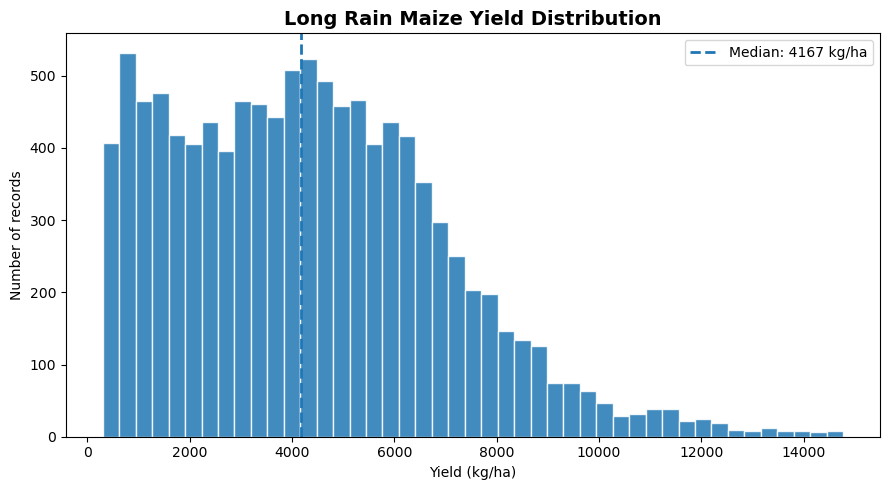

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(maize_clean["yield"].dropna(), bins=45, edgecolor="white", alpha=0.85)
ax.axvline(maize_clean["yield"].median(), linestyle="--", linewidth=2, label=f"Median: {maize_clean['yield'].median():.0f} kg/ha")
ax.set_title("Long Rain Maize Yield Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Yield (kg/ha)")
ax.set_ylabel("Number of records")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "figures" / "long_rain_yield_distribution.png", dpi=300)
plt.show()

**Interpretation:** The Long Rain maize yield distribution is right-skewed, with most observations concentrated between roughly **1,000 and 7,000 kg/ha** and a median yield of about **4,167 kg/ha**. The wide spread supports the need to include environmental information alongside fertilizer rates in the predictive models.


### 3.1.2 Fertilizer Rate Distributions

The N, P and K distributions show how fertilizer treatments are represented in the cleaned dataset. This is important because the predictive models can only learn fertilizer response from treatment rates that are sufficiently represented.


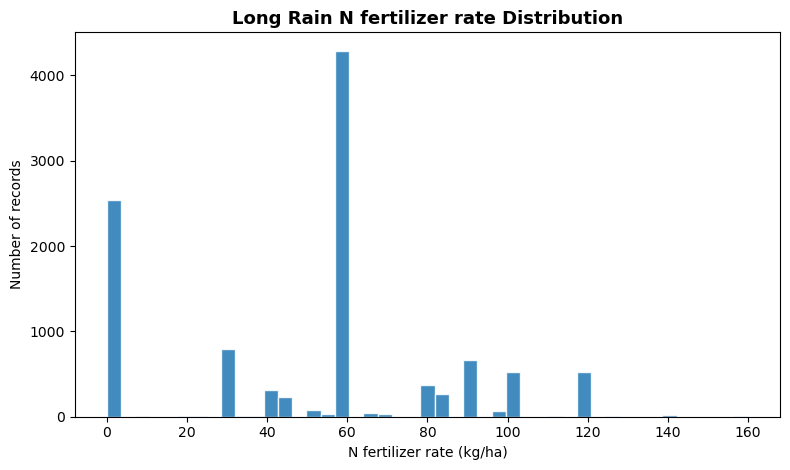

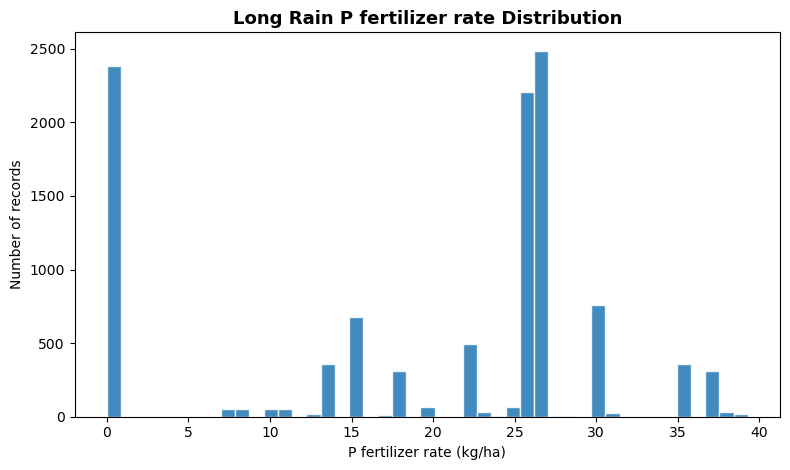

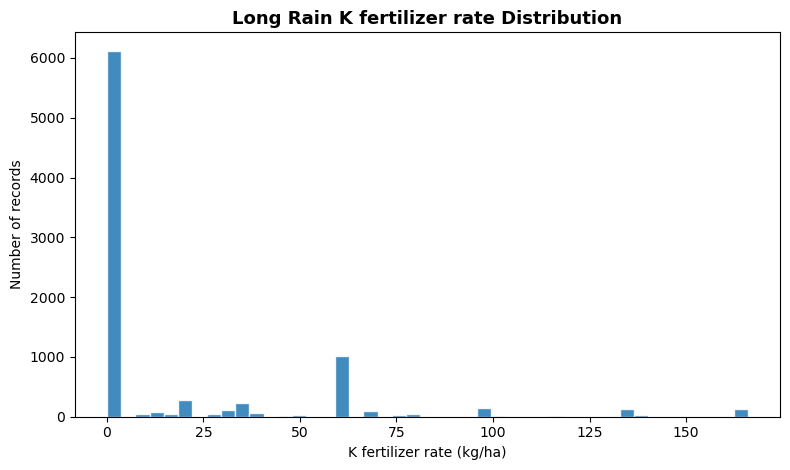

In [21]:
for col, label in [("n", "N fertilizer rate"), ("p", "P fertilizer rate"), ("k", "K fertilizer rate")]:
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.hist(maize_clean[col].dropna(), bins=45, edgecolor="white", alpha=0.85)
    ax.set_title(f"Long Rain {label} Distribution", fontsize=13, fontweight="bold")
    ax.set_xlabel(f"{label} (kg/ha)")
    ax.set_ylabel("Number of records")
    plt.tight_layout()
    plt.savefig(OUTPUTS / "figures" / f"long_rain_{col}_fertilizer_distribution.png", dpi=300)
    plt.show()

**Interpretation:** The fertilizer distributions show repeated treatment rates rather than a continuous range of values. N is commonly applied around **30 to 60 kg/ha**, P is commonly concentrated around **13 to 26 kg/ha**, and many K observations are zero.


### 3.1.3 Temporal and County Coverage

These summaries show how trial records are distributed across years and counties. Uneven coverage is expected in a long-term agronomic dataset and is considered when interpreting the predictive results.


In [22]:
year_counts = maize_clean["year"].value_counts().sort_index().reset_index()
year_counts.columns = ["year", "records"]

#there's data for 1969...but for visualization purposes, let's focus on where we have most data
viz_year_counts = year_counts[year_counts["year"] >= 1995].copy()

fig = px.bar(
    viz_year_counts,
    x="year",
    y="records",
    title="Long Rain Modelling Records by Crop Year",
    labels={"year": "Crop year", "records": "Records"}
)
fit_plotly_window(fig, height=500)
fig.show()
fig.write_html(OUTPUTS / "figures" / "long_rain_records_by_year.html")

display(year_counts.head())
year_counts.to_csv(OUTPUTS / "tables" / "10_long_rain_records_by_year.csv", index=False)

,year,records
0,1969,30
1,1997,2
2,1998,9
3,1999,8
4,2000,4


**Interpretation:** Trial coverage is uneven across time. The dataset includes records from **1969**, but the early years are sparse and most observations occur in later years. This uneven temporal coverage should be considered when interpreting models that combine long-term trial data with newer geospatial products.


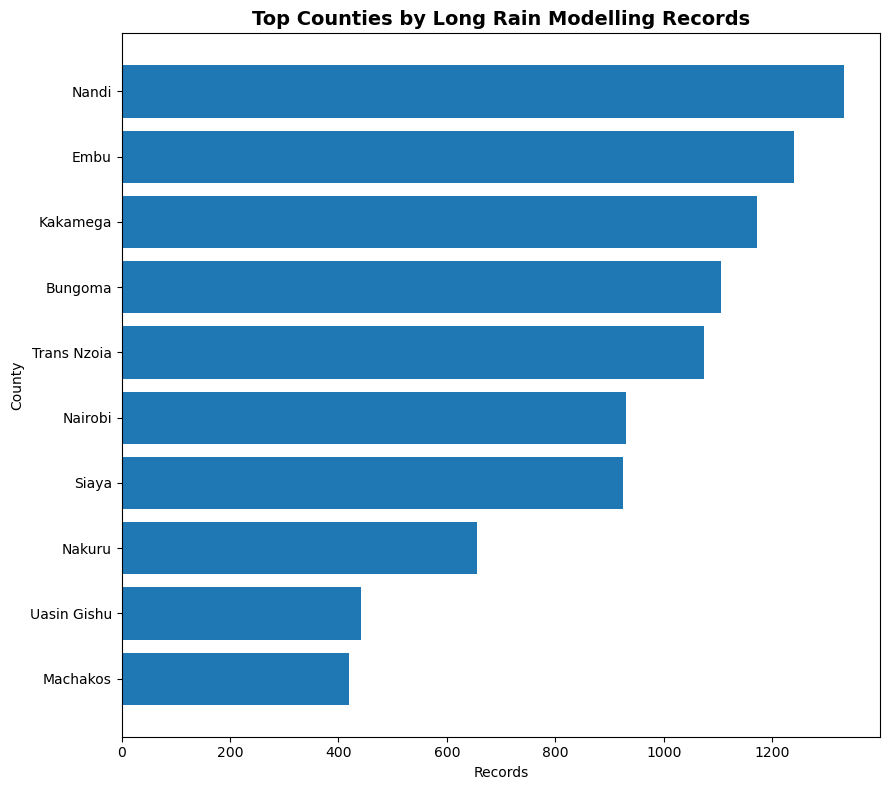

In [23]:
county_counts = maize_clean["county"].value_counts().rename_axis("county").reset_index(name="records")
top_counties = county_counts.head(10) # top 10 counties

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_counties["county"][::-1], top_counties["records"][::-1])
ax.set_title("Top Counties by Long Rain Modelling Records", fontsize=14, fontweight="bold")
ax.set_xlabel("Records")
ax.set_ylabel("County")
plt.tight_layout()
plt.savefig(OUTPUTS / "figures" / "long_rain_records_by_county.png", dpi=300)
plt.show()

#display(county_counts.head(10))
county_counts.to_csv(OUTPUTS / "tables" / "11_long_rain_records_by_county.csv", index=False)

**Interpretation:** Trial observations are not evenly distributed across counties. Counties such as **Nandi, Embu, Kakamega, Bungoma and Trans Nzoia** contribute many records, while other counties have fewer observations. This means some locations have a stronger influence on the overall dataset than others.


### 3.1.4 Yield by County and Common N-P Combinations

County-level yield plots show spatial variation in maize yield. The N-P combination summary shows the fertilizer-treatment structure available for modelling.


In [24]:
top_county_names = county_counts.head(10)["county"].tolist()
county_box_df = maize_clean[maize_clean["county"].isin(top_county_names)].copy()

fig = px.box(
    county_box_df,
    x="county",
    y="yield",
    points="outliers",
    title="Long Rain Yield Distribution by County",
    labels={"county": "County", "yield": "Yield (kg/ha)"}
)
fig.update_layout(height=600, xaxis_tickangle=-45)
fig.show()
fig.write_html(OUTPUTS / "figures" / "long_rain_yield_by_county.html")

**Interpretation:** The county-level boxplots show clear spatial variation in maize yield. Counties such as **Uasin Gishu, Nairobi, Trans Nzoia and Nakuru** have higher median yields, while **Machakos and Bungoma** are lower. The wide spread within several counties also shows substantial variation within the same county.


In [25]:
top_np_combos = (
    maize_clean
    .groupby(["n", "p"], as_index=False)
    .agg(records=("yield", "count"), mean_yield=("yield", "mean"))
    .sort_values("records", ascending=False)
    .head(20)
)

top_np_combos["np_combo"] = "N=" + top_np_combos["n"].astype(str) + ", P=" + top_np_combos["p"].astype(str)

fig = px.bar(
    top_np_combos.sort_values("records"),
    x="records",
    y="np_combo",
    orientation="h",
    title="Top 20 N-P Fertilizer Combinations",
    labels={"records": "Records", "np_combo": "N-P combination"},
    hover_data=["mean_yield"]
)
fit_plotly_window(fig, height=650)
fig.show()
fig.write_html(OUTPUTS / "figures" / "top_np_fertilizer_combinations.html")

#display(top_np_combos)
top_np_combos.to_csv(OUTPUTS / "tables" / "12_top_np_fertilizer_combinations.csv", index=False)

**Interpretation:** The **N = 0, P = 0** control is the most common fertilizer combination. Several N-P treatment combinations are also well represented, particularly treatments around **N = 60 kg/ha** and **P = 25.8 to 26.4 kg/ha**. The treatment distribution is therefore unbalanced, with some combinations represented more strongly than others.


## 3.2 Diagnostic Spatial Analysis

The spatial diagnostic analysis shows the geographic footprint of the cleaned Long Rain observations and the counties represented in the dataset. Mapping the trial points helps confirm that the spatial pattern is reasonable before environmental data are extracted.


In [26]:
maize_clean_gdf = gpd.GeoDataFrame(
    maize_clean.copy(),
    geometry=gpd.points_from_xy(maize_clean["long2"], maize_clean["lat2"]),
    crs="EPSG:4326"
)

county_summary = (
    maize_clean
    .groupby("county", as_index=False)
    .agg(
        n_obs=("yield", "count"),
        mean_yield=("yield", "mean"),
        median_yield=("yield", "median"),
        mean_n=("n", "mean"),
        mean_p=("p", "mean")
    )
)

covered_counties = kenya_adm1.merge(
    county_summary,
    left_on="adm1_gadm",
    right_on="county",
    how="inner"
).copy()

covered_counties.to_file(
    DATA_INTERIM / "geoqa" / "covered_counties_long_rain.gpkg",
    layer="covered_counties",
    driver="GPKG"
)

print("Covered counties:", covered_counties.shape[0])
display(county_summary.sort_values("n_obs", ascending=False).head(10))
county_summary.to_csv(OUTPUTS / "tables" / "13_county_summary_long_rain.csv", index=False)

Covered counties: 28


,county,n_obs,mean_yield,median_yield,mean_n,mean_p
19,Nandi,1332,4874.251160,4765.417578,49.977425,19.076242
3,Embu,1240,4524.039915,4421.989612,51.829839,19.396532
6,Kakamega,1171,4196.953609,4655.033600,48.444919,19.258116
0,Bungoma,1106,2410.848503,2088.099000,40.953354,18.349782
24,Trans Nzoia,1074,5697.838053,5630.217554,53.623510,17.855939
17,Nairobi,931,6743.029663,6159.420290,61.353383,17.658711
22,Siaya,925,3267.305854,3062.352941,33.643243,22.052649
18,Nakuru,656,5296.461053,4975.167575,46.548857,17.764114
25,Uasin Gishu,441,6046.550924,6090.672538,61.207937,20.803717
12,Machakos,419,1166.419925,957.831628,66.169451,15.647685


**Interpretation:** The cleaned Long Rain data cover **28 counties**, but both sample size and yield vary substantially by county. For example, Nandi has the largest number of observations in this summary, while Nairobi, Uasin Gishu and Trans Nzoia show relatively high mean yields and Machakos shows much lower mean yield. This confirms strong spatial variation in the trial data.


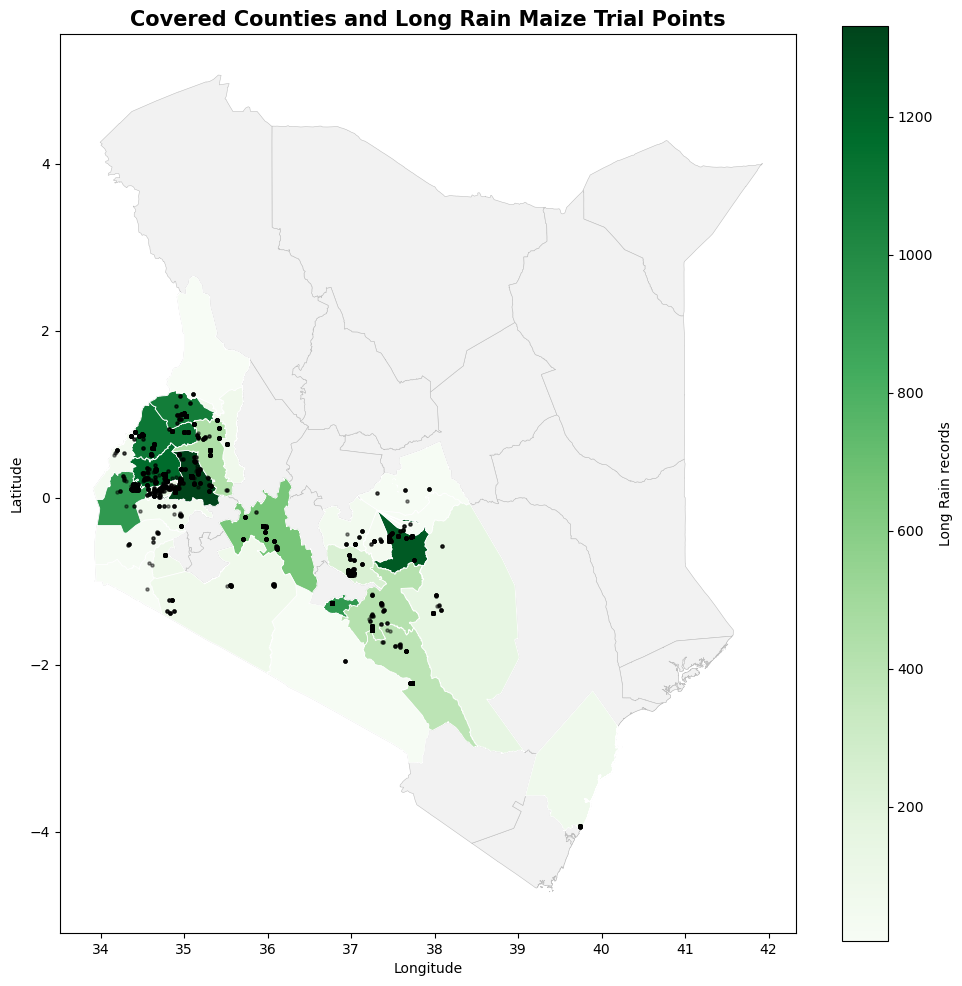

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))

kenya_adm1.plot(
    ax=ax,
    facecolor="0.95",
    edgecolor="0.75",
    linewidth=0.4
)

covered_counties.plot(
    ax=ax,
    column="n_obs",
    cmap="Greens",
    edgecolor="white",
    linewidth=0.6,
    legend=True,
    legend_kwds={"label": "Long Rain records"}
)

maize_clean_gdf.sample(min(8000, len(maize_clean_gdf)), random_state=42).plot(
    ax=ax,
    color="black",
    markersize=5,
    alpha=0.45
)

ax.set_title("Covered Counties and Long Rain Maize Trial Points", fontsize=15, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(OUTPUTS / "maps" / "covered_counties_choropleth_with_points_static.png", dpi=300)
plt.show()

**Interpretation:** The static map shows that trial observations are geographically clustered rather than evenly distributed across Kenya. Much of the coverage is concentrated in western Kenya, with additional observations in central and eastern areas. The point density is consistent with the county record counts shown earlier.


In [28]:
covered_counties_plot = covered_counties.copy()
covered_counties_plot["county_id"] = covered_counties_plot.index.astype(str)

point_sample = maize_clean.sample(
    min(9000, len(maize_clean)),
    random_state=42
).copy()

fig = go.Figure()

fig.add_trace(go.Choroplethmapbox(
    geojson=covered_counties_plot.__geo_interface__,
    locations=covered_counties_plot["county_id"],
    z=covered_counties_plot["n_obs"],
    featureidkey="properties.county_id",
    colorscale="Greens",
    marker_opacity=0.80,
    marker_line_width=0.8,
    marker_line_color="white",
    showscale=False,
    hovertext=(
        "County: " + covered_counties_plot["adm1_gadm"].astype(str) +
        "<br>Records: " + covered_counties_plot["n_obs"].astype(int).astype(str) +
        "<br>Mean yield: " + covered_counties_plot["mean_yield"].round(0).astype(str) + " kg/ha" +
        "<br>Median yield: " + covered_counties_plot["median_yield"].round(0).astype(str) + " kg/ha"
    ),
    hoverinfo="text",
    name="Covered counties"
))

fig.add_trace(go.Scattermapbox(
    lat=point_sample["lat2"],
    lon=point_sample["long2"],
    mode="markers",
    marker=dict(
        size=5,
        opacity=0.65,
        color=point_sample["yield"],
        colorscale="Bluered",
        colorbar=dict(title="Yield<br>(kg/ha)")
    ),
    text=(
        "County: " + point_sample["county"].astype(str) +
        "<br>Year: " + point_sample["year"].astype(str) +
        "<br>Yield: " + point_sample["yield"].round(0).astype(str) + " kg/ha" +
        "<br>N: " + point_sample["n"].round(1).astype(str) +
        "<br>P: " + point_sample["p"].round(1).astype(str)
    ),
    hoverinfo="text",
    name="Maize trial rows"
))

fig.update_layout(
    title="Interactive Long Rain Maize Trial Points by Covered County",

    mapbox=dict(
        style="white-bg", # open-street-map failed. 403 error. Let's try ArcGIS online basemaps

        layers=[
            dict(
                sourcetype="raster",
                source=[
                    "https://server.arcgisonline.com/ArcGIS/rest/services/"
                    "World_Street_Map/MapServer/tile/{z}/{y}/{x}"
                ],
                below="traces"
            )
        ],

        center=dict(lat=0.5, lon=37.5),
        zoom=6.0
    ),

    height=750,
    margin={"r": 0, "t": 55, "l": 0, "b": 0}
)

fig.show()

fig.write_html(
    OUTPUTS / "maps" /
    "interactive_covered_counties_choropleth_with_points.html"
)

**Interpretation:** The interactive map confirms the same spatial pattern as the static map while making it easier to inspect individual locations and county coverage. It is used mainly as a data-coverage and spatial-quality diagnostic rather than as a predictive result.


## 3.3 Seasonal Diagnostic: Short Rain Comparison

Long Rain is the main modelling season. A short comparison with Short Rain is retained to show the wider seasonal structure of the source data and to explain why the predictive analysis focuses on one season.


In [29]:
season_compare = pd.concat([
    maize_clean.assign(model_season_group="Long Rain modelling"),
    maize_short_rain_comparison.assign(model_season_group="Short Rain comparison")
], ignore_index=True)

season_compare_summary = (
    season_compare.groupby("model_season_group")
    .agg(
        records=("yield", "count"),
        counties=("county", "nunique"),
        mean_yield=("yield", "mean"),
        median_yield=("yield", "median"),
        mean_n=("n", "mean"),
        mean_p=("p", "mean")
    )
    .reset_index()
)

display(season_compare_summary)
season_compare_summary.to_csv(OUTPUTS / "tables" / "14_long_vs_short_rain_comparison_summary.csv", index=False)

fig = px.box(
    season_compare,
    x="model_season_group",
    y="yield",
    points="outliers",
    title="Yield Comparison: Long Rain Modelling Data vs Short Rain Comparison Data",
    labels={"model_season_group": "Season group", "yield": "Yield (kg/ha)"}
)
fit_plotly_window(fig, height=550)
fig.show()
fig.write_html(OUTPUTS / "figures" / "long_vs_short_rain_yield_comparison.html")

,model_season_group,records,counties,mean_yield,median_yield,mean_n,mean_p
0,Long Rain modelling,10842,28,4353.546338,4166.666667,51.238765,19.372392
1,Short Rain comparison,4641,19,2507.532659,2183.548190,44.578205,30.906177


**Interpretation:** Long Rain contains **10,842 observations across 28 counties**, compared with **4,641 Short Rain observations across 19 counties**. Mean Long Rain yield is about **4,354 kg/ha**, compared with about **2,508 kg/ha** for Short Rain. The seasonal differences in yield and fertilizer rates support modelling Long Rain separately in this project.


# Objective 4: Extract and Integrate Climate, Soil and Topographic Variables

## 4.1 Pre-treatment for Machine Learning: Create GEE Lookup Tables

The original Long Rain data remain at row level. Separate lookup tables are created only to reduce repeated geospatial extraction:

- coordinate-year lookup for climate and annual data;
- coordinate lookup for soil and topography.

These lookup tables are extraction tools and are not used as the final modelling datasets.


In [30]:
# All Long Rain rows retain their original point_key and coord_key.
assert maize_clean["unique_row_id"].is_unique, "unique_row_id should be unique in row-level maize_clean."

# Climate varies by coordinate-year, so this lookup uses point_key.
# It does not include yield or fertilizer summaries because it is not a modelling table.
gee_lookup_climate = (
    maize_clean[
        maize_clean["year"].ge(CLIMATE_MIN_YEAR)
    ][["point_key", "coord_key", "long2", "lat2", "year", "county"]]
    .drop_duplicates("point_key")
    .copy()
)

# Soil/topography are treated as static at this project scale, so extraction is once per coordinate.
gee_lookup_soil_topo = (
    maize_clean[["coord_key", "long2", "lat2", "county"]]
    .drop_duplicates("coord_key")
    .copy()
)

# Candidate AlphaEarth lookup: annual embeddings begin in 2017.
# The final eligible years are filtered dynamically after Earth Engine confirms availability.
gee_lookup_alphaearth_candidates = (
    maize_clean[
        maize_clean["year"].ge(ALPHAEARTH_MIN_YEAR)
    ][["point_key", "coord_key", "long2", "lat2", "year", "county"]]
    .drop_duplicates("point_key")
    .copy()
)

gee_lookup_climate["geo_extract_id"] = np.arange(1, len(gee_lookup_climate) + 1)
gee_lookup_soil_topo["geo_extract_id"] = np.arange(1, len(gee_lookup_soil_topo) + 1)
gee_lookup_alphaearth_candidates["geo_extract_id"] = np.arange(1, len(gee_lookup_alphaearth_candidates) + 1)

lookup_summary_initial = pd.DataFrame({
    "lookup_table": [
        "Long Rain row-level modelling table",
        "Climate coordinate-year lookup",
        "Soil/topography coordinate lookup",
        "AlphaEarth candidate coordinate-year lookup, 2017 onward"
    ],
    "records": [
        len(maize_clean),
        len(gee_lookup_climate),
        len(gee_lookup_soil_topo),
        len(gee_lookup_alphaearth_candidates)
    ]
})

display(lookup_summary_initial)

gee_lookup_climate.to_csv(DATA_INTERIM / "gee_exports" / "gee_lookup_climate_coordinate_year.csv", index=False)
gee_lookup_soil_topo.to_csv(DATA_INTERIM / "gee_exports" / "gee_lookup_soil_topo_coordinate.csv", index=False)
gee_lookup_alphaearth_candidates.to_csv(DATA_INTERIM / "gee_exports" / "gee_lookup_alphaearth_candidates_coordinate_year_2017_onward.csv", index=False)
lookup_summary_initial.to_csv(OUTPUTS / "tables" / "15_gee_lookup_summary_initial.csv", index=False)

,lookup_table,records
0,Long Rain row-level modelling table,10842
1,Climate coordinate-year lookup,623
2,Soil/topography coordinate lookup,523
3,"AlphaEarth candidate coordinate-year lookup, 2...",178


**Interpretation:** The **10,842 row-level trial observations** can be represented by only **623 climate coordinate-year keys**, **523 unique soil/topography coordinates**, and **178 AlphaEarth coordinate-year keys**. The lookup approach therefore reduces repeated geospatial extraction while preserving all treatment-level trial rows.


In [31]:
# Audit-only table: this helps understand repeated trial rows per coordinate-year.
# It is not used as a modelling table.

gee_lookup_audit = (
    maize_clean
    .groupby(["point_key", "long2", "lat2", "year"], as_index=False)
    .agg(
        n_trial_rows=("unique_row_id", "count"),
        unique_yields=("yield", "nunique"),
        yield_min=("yield", "min"),
        yield_median=("yield", "median"),
        yield_max=("yield", "max"),
        n_unique_N=("n", "nunique"),
        n_unique_P=("p", "nunique"),
        n_unique_K=("k", "nunique")
    )
    .sort_values("n_trial_rows", ascending=False)
)

display(gee_lookup_audit.shape)
display(gee_lookup_audit.head(10))
gee_lookup_audit.to_csv(OUTPUTS / "tables" / "16_coordinate_year_trial_row_audit_not_for_modelling.csv", index=False)

(640, 12)

,point_key,long2,lat2,year,n_trial_rows,unique_yields,yield_min,yield_median,yield_max,n_unique_N,n_unique_P,n_unique_K
154,34.62146_0.59928_2016,34.621460,0.599280,2016,470,451,318.523300,1303.343150,7717.000000,7,6,12
350,35.085006_0.256974_2016,35.085006,0.256974,2016,389,388,634.065900,4145.041800,11168.153100,7,6,12
584,37.4564_-0.5052_2019,37.456400,-0.505200,2019,327,327,1685.446299,6328.526133,11909.627610,1,1,0
219,34.7523_0.2842_2016,34.752300,0.284200,2016,283,274,304.000000,2522.000000,7941.000000,3,3,11
345,35.016705_0.979776_2016,35.016705,0.979776,2016,276,276,2312.373200,6152.146800,11808.333300,3,4,6
580,37.452_-0.494_2015,37.452000,-0.494000,2015,259,259,929.069767,4021.663953,6997.760465,5,4,4
351,35.085006_0.256974_2017,35.085006,0.256974,2017,241,241,462.268900,5207.784100,11493.424900,3,4,6
455,35.946747_-0.342644_2016,35.946747,-0.342644,2016,236,174,1444.444400,5237.349750,10740.740700,3,6,10
228,34.76345_0.2777_2016,34.763450,0.277700,2016,228,227,303.771100,1913.897800,7940.939600,2,3,6
338,34.992444_1.00038_2016,34.992444,1.000380,2016,205,205,2792.500982,6882.217090,11808.333330,2,3,9


**Interpretation:** Several treatment observations occur at the same coordinate and year. Some coordinate-year groups contain many trial rows with different fertilizer treatments and yields. The audit confirms why geospatial extraction should be done once per location or coordinate-year and then joined back to the original trial rows.


## 4.2 Initialise Google Earth Engine and Check Data Availability

Google Earth Engine is initialised before geospatial extraction. The available years for annual satellite embeddings are checked directly so that only supported trial years are used during extraction.


In [32]:
import ee
import geemap

GEE_PROJECT_ID = "gacheri" # my GEE project ID


ee.Authenticate()

ee.Initialize(project=GEE_PROJECT_ID)

print("Earth Engine initialized.")

# Check available AlphaEarth/Satellite Embedding years dynamically
alpha_collection = ee.ImageCollection(ALPHAEARTH_COLLECTION)

available_alphaearth_years = (
    alpha_collection
    .aggregate_array("system:time_start")
    .map(lambda t: ee.Date(t).get("year"))
    .distinct()
    .sort()
    .getInfo()
)

available_alphaearth_years = [int(y) for y in available_alphaearth_years]
print("AlphaEarth years available in this Earth Engine collection:", available_alphaearth_years)

if len(available_alphaearth_years) == 0:
    raise ValueError("No AlphaEarth years were returned from the Earth Engine collection. Check collection access.")

# Create the final AlphaEarth lookup using only years available in the active Earth Engine collection.
gee_lookup_alphaearth = (
    gee_lookup_alphaearth_candidates[
        gee_lookup_alphaearth_candidates["year"].astype(int).isin(available_alphaearth_years)
    ]
    .copy()
    .reset_index(drop=True)
)

gee_lookup_alphaearth["geo_extract_id"] = np.arange(1, len(gee_lookup_alphaearth) + 1)

alpha_year_summary = pd.DataFrame({
    "item": [
        "Available AlphaEarth years in active Earth Engine collection",
        "Candidate coordinate-year keys from 2017 onward",
        "Eligible AlphaEarth coordinate-year keys after dynamic year check"
    ],
    "value": [
        ", ".join(map(str, available_alphaearth_years)),
        len(gee_lookup_alphaearth_candidates),
        len(gee_lookup_alphaearth)
    ]
})

display(alpha_year_summary)

gee_lookup_alphaearth.to_csv(
    DATA_INTERIM / "gee_exports" / "gee_lookup_alphaearth_coordinate_year_available_years.csv",
    index=False
)

alpha_year_summary.to_csv(
    OUTPUTS / "tables" / "16_alphaearth_available_years_and_lookup_summary.csv",
    index=False
)

Earth Engine initialized.
AlphaEarth years available in this Earth Engine collection: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,item,value
0,Available AlphaEarth years in active Earth Eng...,"2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024..."
1,Candidate coordinate-year keys from 2017 onward,178
2,Eligible AlphaEarth coordinate-year keys after...,178


**Interpretation:** AlphaEarth data are available for **2017 to 2025** in the active Earth Engine collection. The dynamic year check ensures that only supported coordinate-year records are sent for embedding extraction and avoids assuming that the satellite product covers the full historical trial period.


## 4.3 Convert Lookup Tables to Earth Engine FeatureCollections

The lookup tables are converted to Earth Engine `FeatureCollection` objects so that image values can be sampled at the trial locations. Identifiers such as `point_key` and `coord_key` are retained to support accurate merging back to the row-level trial data.


In [33]:
def pandas_points_to_ee_fc(df, lon_col, lat_col, property_cols):
    features = []

    for _, row in df.iterrows():
        props = {}

        for col in property_cols:
            value = row[col]
            if pd.isna(value):
                props[col] = None
            elif isinstance(value, (np.integer, int)):
                props[col] = int(value)
            elif isinstance(value, (np.floating, float)):
                props[col] = float(value)
            else:
                props[col] = str(value)

        geom = ee.Geometry.Point([float(row[lon_col]), float(row[lat_col])])
        features.append(ee.Feature(geom, props))

    return ee.FeatureCollection(features)

climate_props = ["geo_extract_id", "point_key", "coord_key", "year", "long2", "lat2", "county"]
soil_props = ["geo_extract_id", "coord_key", "long2", "lat2", "county"]
alpha_props = ["geo_extract_id", "point_key", "coord_key", "year", "long2", "lat2", "county"]

points_fc_climate = pandas_points_to_ee_fc(gee_lookup_climate, "long2", "lat2", climate_props)
points_fc_soil_topo = pandas_points_to_ee_fc(gee_lookup_soil_topo, "long2", "lat2", soil_props)
points_fc_alphaearth = pandas_points_to_ee_fc(gee_lookup_alphaearth, "long2", "lat2", alpha_props)

print("Climate points:", points_fc_climate.size().getInfo())
print("Soil/topo points:", points_fc_soil_topo.size().getInfo())
print("AlphaEarth points after dynamic availability check:", points_fc_alphaearth.size().getInfo())

Climate points: 623
Soil/topo points: 523
AlphaEarth points after dynamic availability check: 178


**Explanation:** The Earth Engine lookup tables contain **623 climate points**, **523 soil/topography points**, and **178 AlphaEarth points**. The counts match the prepared lookup tables and confirm that the data are ready for geospatial sampling.


## 4.4 Extract Climate Variables

CHIRPS daily precipitation is used for seasonal rainfall information. ERA5-Land monthly data provide additional climate variables such as temperature, solar radiation, wind speed and relative humidity. These variables provide seasonal environmental context for predictive modelling.


In [34]:
ERA5 = "ECMWF/ERA5_LAND/MONTHLY_AGGR"
CHIRPS = "UCSB-CHG/CHIRPS/DAILY"

def relative_humidity_from_temperature_dewpoint(t_c, td_c):
    numerator = td_c.multiply(17.625).divide(td_c.add(243.04)).exp()
    denominator = t_c.multiply(17.625).divide(t_c.add(243.04)).exp()
    return numerator.divide(denominator).multiply(100)

def era5_non_rain_month_image(year, month, model_month_index):
    img = (
        ee.ImageCollection(ERA5)
        .filter(ee.Filter.calendarRange(int(year), int(year), "year"))
        .filter(ee.Filter.calendarRange(int(month), int(month), "month"))
        .first()
    )

    t_mean_c = img.select("temperature_2m").subtract(273.15)
    td_c = img.select("dewpoint_temperature_2m").subtract(273.15)

    temp_max = img.select("temperature_2m_max").subtract(273.15).rename(f"TemperatureMax_m{model_month_index}")
    temp_min = img.select("temperature_2m_min").subtract(273.15).rename(f"TemperatureMin_m{model_month_index}")
    solar = img.select("surface_solar_radiation_downwards_sum").divide(1e6).rename(f"SolarRadiation_m{model_month_index}")

    wind = (
        img.select("u_component_of_wind_10m").pow(2)
        .add(img.select("v_component_of_wind_10m").pow(2))
        .sqrt()
        .rename(f"WindSpeed_m{model_month_index}")
    )

    rh = relative_humidity_from_temperature_dewpoint(t_mean_c, td_c).rename(f"RelativeHumidity_m{model_month_index}")
    return temp_max.addBands([temp_min, solar, wind, rh])

def chirps_monthly_rainfall_image(year, month, model_month_index):
    start = ee.Date.fromYMD(int(year), int(month), 1)
    end = start.advance(1, "month")

    return (
        ee.ImageCollection(CHIRPS)
        .filterDate(start, end)
        .select("precipitation")
        .sum()
        .rename(f"Precipitation_m{model_month_index}")
    )

def agwise_style_climate_stack(year):
    era5_images = []
    chirps_images = []

    for i, month in enumerate(range(3, 13), start=1):
        era5_images.append(era5_non_rain_month_image(year, month, i))
        chirps_images.append(chirps_monthly_rainfall_image(year, month, i))

    era5_stack = ee.Image.cat(era5_images)
    chirps_stack = ee.Image.cat(chirps_images)
    chirps_total = chirps_stack.reduce(ee.Reducer.sum()).rename("Precipitation_Mar_Dec_total")

    return era5_stack.addBands(chirps_stack).addBands(chirps_total)

def sample_climate_by_year(points_fc, years, scale=5566):
    all_samples = ee.FeatureCollection([])
    props = ["geo_extract_id", "point_key", "coord_key", "year", "long2", "lat2", "county"]

    for year in years:
        img = agwise_style_climate_stack(year)
        fc_year = points_fc.filter(ee.Filter.eq("year", int(year)))

        sampled = img.sampleRegions(
            collection=fc_year,
            properties=props,
            scale=scale,
            geometries=True,
            tileScale=4
        )
        all_samples = all_samples.merge(sampled)

    return all_samples

CLIMATE_OUT = DATA_INTERIM / "gee_exports" / "long_rain_climate_chirps_rainfall_era5_nonrain.csv"

years_for_climate = sorted(gee_lookup_climate["year"].dropna().astype(int).unique())
print("Years for climate extraction:", years_for_climate)

climate_fc = sample_climate_by_year(points_fc_climate, years_for_climate)
climate_df = geemap.ee_to_df(climate_fc)
climate_df.to_csv(CLIMATE_OUT, index=False)

print("Climate feature table:", climate_df.shape)
display(climate_df.head())

Years for climate extraction: [np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Climate feature table: (623, 68)


,Precipitation_Mar_Dec_total,Precipitation_m1,Precipitation_m10,Precipitation_m2,Precipitation_m3,Precipitation_m4,Precipitation_m5,Precipitation_m6,Precipitation_m7,Precipitation_m8,Precipitation_m9,RelativeHumidity_m1,RelativeHumidity_m10,RelativeHumidity_m2,RelativeHumidity_m3,RelativeHumidity_m4,RelativeHumidity_m5,RelativeHumidity_m6,RelativeHumidity_m7,RelativeHumidity_m8,RelativeHumidity_m9,SolarRadiation_m1,SolarRadiation_m10,SolarRadiation_m2,SolarRadiation_m3,SolarRadiation_m4,SolarRadiation_m5,SolarRadiation_m6,SolarRadiation_m7,SolarRadiation_m8,SolarRadiation_m9,TemperatureMax_m1,TemperatureMax_m10,TemperatureMax_m2,TemperatureMax_m3,TemperatureMax_m4,TemperatureMax_m5,TemperatureMax_m6,TemperatureMax_m7,TemperatureMax_m8,TemperatureMax_m9,TemperatureMin_m1,TemperatureMin_m10,TemperatureMin_m2,TemperatureMin_m3,TemperatureMin_m4,TemperatureMin_m5,TemperatureMin_m6,TemperatureMin_m7,TemperatureMin_m8,TemperatureMin_m9,WindSpeed_m1,WindSpeed_m10,WindSpeed_m2,WindSpeed_m3,WindSpeed_m4,WindSpeed_m5,WindSpeed_m6,WindSpeed_m7,WindSpeed_m8,WindSpeed_m9,coord_key,county,geo_extract_id,lat2,long2,point_key,year
0,1781.109277,129.435918,272.230931,323.652693,209.346103,185.361802,75.207684,160.524479,31.094615,165.008484,229.246568,60.765300,85.374869,83.709162,81.587295,78.294245,78.382493,73.116356,68.639726,80.466497,86.766016,743.660873,611.654600,570.904950,631.813568,587.112202,574.228020,639.741944,720.547429,670.446440,546.636060,33.195413,26.368646,27.689264,27.350366,26.643732,26.351328,27.151392,29.491388,28.225244,27.248438,16.415521,14.413980,15.617136,14.334650,15.187952,14.473062,14.425195,15.273477,14.797693,14.859369,0.327536,0.117120,0.150088,0.027386,0.250652,0.313241,0.611471,0.121989,0.166131,0.023384,34.55_0.15,Kakamega,582,0.15000,34.5500,34.55_0.15_1997,1997
1,1265.486681,37.293232,30.260864,367.437168,370.962409,103.477451,94.842177,83.469234,36.798086,67.902293,73.043766,79.132487,74.697747,81.796071,79.923948,79.765882,79.817274,79.918495,78.817594,73.398616,74.953050,693.976613,687.075888,571.541356,528.990222,506.562528,566.617456,623.601634,637.487499,709.082666,660.610180,32.109872,31.666788,32.585779,30.425287,28.996072,27.635339,27.527444,28.691843,30.518640,31.072794,23.928995,22.861887,22.717050,22.845544,22.029077,20.579080,21.019449,21.323709,21.032220,21.899683,1.313539,2.747609,3.290447,4.465807,5.061021,4.913072,4.396194,4.169138,3.528998,2.242994,39.7453_-3.94355,Kilifi,572,-3.94355,39.7453,39.7453_-3.94355_1998,1998
2,1511.884677,120.543365,25.845469,337.767601,272.503432,189.389491,106.564615,89.378666,137.512636,156.904797,75.474604,74.224312,63.877638,83.521369,83.222521,80.641683,76.882520,76.494897,75.448543,76.724276,72.493121,758.468639,731.345276,648.335816,597.187982,567.779520,562.348428,607.469444,665.501603,642.806654,662.516700,30.433588,29.575143,29.218851,27.492120,26.480981,26.158792,26.747797,28.361017,27.676233,28.132837,16.140390,15.356638,16.093484,15.587656,14.755350,15.312814,14.554483,14.638315,15.171762,15.012491,0.279010,0.438183,0.259058,0.132437,0.288208,0.371404,0.339212,0.452914,0.440835,0.351183,34.55_0.15,Kakamega,583,0.15000,34.5500,34.55_0.15_1998,1998
3,1404.188623,98.701434,24.397373,314.267221,205.132134,196.566621,107.717030,96.145972,140.181354,143.129717,77.949765,74.996763,65.551519,83.603031,82.625346,79.815996,76.338154,76.148270,75.117817,76.602423,73.142385,766.336597,736.511952,661.568492,604.546664,575.454176,569.699122,614.274146,670.299929,645.544710,668.335696,29.227579,28.315332,27.894632,26.365167,25.481790,24.982919,25.466104,26.870782,26.319635,26.835962,15.654916,14.962106,16.799265,15.529718,14.694803,15.103830,14.294717,14.321909,15.351450,15.113275,0.302144,0.314187,0.316250,0.082053,0.200545,0.326273,0.208536,0.369227,0.402700,0.304618,34.57_0.1,Vihiga,588,0.10000,34.5700,34.57_0.1_1998,1998
4,1350.458698,38.590806,55.621414,330.359344,245.021179,147.584244,115.793245,127.425175,47.657201,79.672660,162.733429,74.534972,76.896

**Interpretation:** Climate extraction is limited to trial years supported by the selected climate datasets, beginning in **1997**. Monthly precipitation and other climate variables are extracted for the coordinate-year locations and later joined back to the trial observations.


## 4.5 Extract Soil and Topographic Variables

Soil properties are extracted from SoilGrids and topographic variables are derived from SRTM elevation. These variables provide relatively stable information about site conditions that may help explain spatial differences in maize yield.


In [35]:
def soil_topography_image():
    dem = ee.Image("USGS/SRTMGL1_003").rename("elevation")
    terrain = ee.Terrain.products(dem)
    slope = terrain.select("slope").rename("slope")
    aspect = terrain.select("aspect").rename("aspect")

    ph = ee.Image("projects/soilgrids-isric/phh2o_mean").select("phh2o_0-5cm_mean").divide(10).rename("soil_ph")
    soc = ee.Image("projects/soilgrids-isric/soc_mean").select("soc_0-5cm_mean").divide(10).rename("soil_soc")
    nitrogen = ee.Image("projects/soilgrids-isric/nitrogen_mean").select("nitrogen_0-5cm_mean").rename("soil_nitrogen")
    clay = ee.Image("projects/soilgrids-isric/clay_mean").select("clay_0-5cm_mean").divide(10).rename("soil_clay")
    sand = ee.Image("projects/soilgrids-isric/sand_mean").select("sand_0-5cm_mean").divide(10).rename("soil_sand")
    silt = ee.Image("projects/soilgrids-isric/silt_mean").select("silt_0-5cm_mean").divide(10).rename("soil_silt")
    cec = ee.Image("projects/soilgrids-isric/cec_mean").select("cec_0-5cm_mean").divide(10).rename("soil_cec")

    return dem.addBands([slope, aspect, ph, soc, nitrogen, clay, sand, silt, cec])

SOIL_TOPO_OUT = DATA_INTERIM / "gee_exports" / "long_rain_soil_topography_by_coord.csv"

soil_topo_fc = soil_topography_image().sampleRegions(
    collection=points_fc_soil_topo,
    properties=["geo_extract_id", "coord_key", "long2", "lat2", "county"],
    scale=250,
    geometries=True,
    tileScale=4
)

soil_topo_df = geemap.ee_to_df(soil_topo_fc)
soil_topo_df.to_csv(SOIL_TOPO_OUT, index=False)

print("Soil/topography feature table:", soil_topo_df.shape)
display(soil_topo_df.head())

Soil/topography feature table: (518, 15)


,aspect,coord_key,county,elevation,geo_extract_id,lat2,long2,slope,soil_cec,soil_clay,soil_nitrogen,soil_ph,soil_sand,soil_silt,soil_soc
0,288,36.919722_-1.951389,Kajiado,1723,1,-1.951389,36.919722,2,21.799999,35.000000,1644,6.5,46.599998,18.400000,21.799999
1,90,34.621_0.6,Bungoma,1518,2,0.600000,34.621000,1,18.600000,40.700001,3456,5.6,30.900000,28.500000,47.599998
2,321,35.085159_0.259622,Nandi,1978,3,0.259622,35.085159,1,23.400000,36.200001,3760,5.6,32.500000,31.299999,48.799999
3,242,35.016684_0.979931,Trans Nzoia,1898,4,0.979931,35.016684,2,32.000000,45.500000,3696,6.0,17.500000,37.000000,36.799999
4,242,35.016716_0.980049,Trans Nzoia,1898,5,0.980049,35.016716,2,32.000000,45.500000,3696,6.0,17.500000,37.000000,36.799999


**Interpretation:** Soil and topographic information is successfully extracted for **518 unique locations**. The output includes elevation, slope, aspect and several soil properties such as pH, organic carbon, nitrogen, texture and CEC. These variables are treated as location-based features because they change much more slowly than monthly climate conditions.


# Objective 5: Integrate AlphaEarth Satellite Embeddings

## 5.1 Extract AlphaEarth Embeddings

AlphaEarth embeddings are extracted for coordinate-year combinations with available annual data. Each valid coordinate-year receives a 64-dimensional embedding vector from `A00` to `A63`. The individual dimensions are not interpreted as separate physical variables. Instead, they are tested as a learned representation of environmental and landscape conditions.


In [36]:
ALPHAEARTH = ALPHAEARTH_COLLECTION
ALPHA_BANDS = [f"A{i:02d}" for i in range(64)]

def alphaearth_image(year):
    return (
        ee.ImageCollection(ALPHAEARTH)
        .filterDate(f"{int(year)}-01-01", f"{int(year) + 1}-01-01")
        .mosaic()
        .select(ALPHA_BANDS)
    )

def sample_alphaearth_by_year(points_fc, years, scale=10):
    all_samples = ee.FeatureCollection([])
    props = ["geo_extract_id", "point_key", "coord_key", "year", "long2", "lat2", "county"]

    for year in years:
        img = alphaearth_image(year)
        fc_year = points_fc.filter(ee.Filter.eq("year", int(year)))

        sampled = img.sampleRegions(
            collection=fc_year,
            properties=props,
            scale=scale,
            geometries=True,
            tileScale=4
        )
        all_samples = all_samples.merge(sampled)

    return all_samples

ALPHA_OUT = DATA_INTERIM / "gee_exports" / "long_rain_alphaearth_embeddings_by_point_key_available_years.csv"

years_for_alphaearth = sorted(gee_lookup_alphaearth["year"].dropna().astype(int).unique())
print("Years selected for AlphaEarth extraction:", years_for_alphaearth)

if len(years_for_alphaearth) == 0:
    raise ValueError("No rows are eligible for AlphaEarth extraction after the dynamic year availability check.")

alpha_fc = sample_alphaearth_by_year(points_fc_alphaearth, years_for_alphaearth)
alpha_df = geemap.ee_to_df(alpha_fc)
alpha_df.to_csv(ALPHA_OUT, index=False)

print("AlphaEarth embedding table:", alpha_df.shape)
display(alpha_df.head())

Years selected for AlphaEarth extraction: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
AlphaEarth embedding table: (178, 71)


,A00,A01,A02,A03,A04,A05,A06,A07,A08,A09,A10,A11,A12,A13,A14,A15,A16,A17,A18,A19,A20,A21,A22,A23,A24,A25,A26,A27,A28,A29,A30,A31,A32,A33,A34,A35,A36,A37,A38,A39,A40,A41,A42,A43,A44,A45,A46,A47,A48,A49,A50,A51,A52,A53,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63,coord_key,county,geo_extract_id,lat2,long2,point_key,year
0,-0.001538,0.055363,0.221453,-0.172795,-0.024606,0.027128,0.008858,0.088827,0.059116,-0.160000,-0.013841,-0.236463,-0.135886,-0.002215,-0.024606,-0.135886,-0.192910,0.075356,-0.035433,-0.041584,-0.108512,0.088827,0.192910,-0.041584,-0.153787,-0.103406,-0.006151,0.019931,-0.079723,-0.088827,-0.147697,0.166336,-0.251965,-0.013841,0.130165,-0.251965,0.044844,0.048228,0.055363,0.003937,-0.004983,-0.124567,-0.327812,-0.024606,0.055363,-0.124567,-0.084214,0.119093,-0.119093,-0.071111,0.079723,0.172795,-0.079723,0.135886,0.206936,0.079723,0.130165,0.071111,-0.153787,-0.147697,-0.130165,-0.093564,0.130165,-0.166336,35.016705_0.979776,Trans Nzoia,2,0.979776,35.016705,35.016705_0.979776_2017,2017
1,0.051734,-0.048228,0.147697,-0.108512,0.048228,0.006151,-0.048228,0.027128,0.141730,-0.130165,-0.079723,-0.179377,-0.160000,0.006151,-0.012057,-0.147697,-0.236463,0.032541,-0.084214,-0.013841,-0.044844,0.062991,0.172795,0.015748,-0.108512,-0.044844,0.048228,0.003937,-0.013841,-0.062991,-0.236463,0.124567,-0.292872,-0.124567,0.075356,-0.276140,0.059116,-0.066990,0.147697,-0.062991,0.003014,-0.147697,-0.292872,-0.004983,0.027128,-0.147697,-0.041584,0.017778,-0.192910,-0.055363,0.051734,0.098424,-0.093564,0.093564,0.199862,0.079723,0.113741,0.088827,-0.244152,-0.166336,-0.055363,-0.027128,0.130165,-0.199862,35.085006_0.256974,Nandi,3,0.256974,35.085006,35.085006_0.256974_2017,2017
2,-0.029773,0.084214,0.062991,0.098424,0.062991,0.130165,-0.051734,0.051734,-0.017778,-0.124567,0.044844,-0.186082,-0.284444,-0.055363,0.012057,-0.186082,-0.160000,0.051734,0.071111,-0.059116,0.119093,0.124567,0.055363,-0.071111,-0.135886,-0.051734,0.228897,0.088827,-0.113741,-0.124567,-0.130165,0.135886,-0.066990,-0.141730,-0.003937,-0.206936,0.079723,-0.038447,0.098424,0.186082,0.160000,-0.038447,-0.119093,-0.124567,-0.147697,-0.284444,-0.044844,-0.119093,-0.022207,-0.135886,0.124567,0.147697,-0.098424,0.179377,0.172795,0.113741,0.066990,0.041584,-0.284444,-0.027128,0.029773,0.153787,0.103406,-0.059116,35.55765_-1.04571,Narok,5,-1.045710,35.557650,35.55765_-1.04571_2017,2017
3,0.130165,0.044844,0.103406,-0.130165,0.059116,-0.000984,-0.055363,0.044844,0.088827,-0.098424,-0.055363,-0.062991,-0.199862,-0.022207,0.055363,-0.130165,-0.228897,0.113741,-0.088827,0.098424,-0.166336,0.019931,0.160000,0.147697,-0.048228,-0.044844,0.071111,-0.038447,0.001538,-0.084214,-0.221453,0.141730,-0.130165,-0.113741,0.113741,-0.228897,0.119093,-0.103406,0.147697,-0.075356,-0.108512,-0.113741,-0.310096,0.010396,0.088827,-0.093564,-0.088827,-0.041584,-0.172795,0.108512,0.062991,0.088827,-0.153787,0.041584,0.236463,0.093564,0.172795,-0.015748,-0.214133,-0.214133,-0.098424,0.027128,0.079723,-0.179377,34.767153_0.279949,Kakamega,64,0.279949,34.767153,34.767153_0.279949_2017,2017
4,-0.071111,0.124567,-0.035433,-0.075356,-0.141730,0.075356,-0.024606,0.160000,-0.066990,-0.221453,-0.003937,-0.027128,-0.141730,0.066990,-0.079723,-0.135886,-0.017778,0.079723,-0.032541,0.019931,0.141730,0.124567,0.055363,0.124567,-0.113741,-0.141730,0.124567,-0.029773,-0.098424,0.010396,-0.179377,-0.098424,0.008858,-0.166336,0.147697,0.093564,0.098424,-0.035433,0.044844,0.192910,-0.006151,-0.206936,-0.141730,-0.032541,-0.336855,-0.276140,-0.038447,-0.059116,0.001538,-0.059116,0.141730,0.124567,-0.017778,0.336855,-0.010396,0.084214,0.066990,-0.035433,-0.284444,-0.088827,0.135886,0.093564,0.093564,0.010396,37.723118_-2.214365,Makueni,65,-2.214365,37.723118,37.723118_-2.214365_2017,2017


**Interpretation:** AlphaEarth embeddings are extracted for all **178 eligible coordinate-year locations** from **2017 to 2025**. Each location receives **64 embedding dimensions**, together with the metadata needed to link the embeddings back to the trial observations.


## 5.2 Clean Extracted Feature Tables

The raw Earth Engine output tables are cleaned by removing system and geometry fields and resolving duplicate keys. The result is a set of feature tables that can be joined back to the original trial observations.


In [37]:
def clean_gee_feature_table(df, key_col, metadata_cols):
    df = df.copy()
    df = df.drop(columns=[c for c in ["geo", ".geo", "system:index"] if c in df.columns], errors="ignore")
    df = df.drop_duplicates(key_col)

    feature_cols = [c for c in df.columns if c not in metadata_cols + [key_col]]
    return df[[key_col] + feature_cols]

climate_raw = pd.read_csv(CLIMATE_OUT)
soil_topo_raw = pd.read_csv(SOIL_TOPO_OUT)
alpha_raw = pd.read_csv(ALPHA_OUT)

climate_features_df = clean_gee_feature_table(
    climate_raw,
    key_col="point_key",
    metadata_cols=["geo_extract_id", "coord_key", "year", "long2", "lat2", "county"]
)

soil_topo_features_df = clean_gee_feature_table(
    soil_topo_raw,
    key_col="coord_key",
    metadata_cols=["geo_extract_id", "long2", "lat2", "county"]
)

alpha_features_df = clean_gee_feature_table(
    alpha_raw,
    key_col="point_key",
    metadata_cols=["geo_extract_id", "coord_key", "year", "long2", "lat2", "county"]
)

print("Climate features:", climate_features_df.shape)
print("Soil/topography features:", soil_topo_features_df.shape)
print("AlphaEarth features:", alpha_features_df.shape)

feature_table_shapes = pd.DataFrame({
    "feature_table": ["climate", "soil_topography", "alphaearth"],
    "rows": [len(climate_features_df), len(soil_topo_features_df), len(alpha_features_df)],
    "columns": [climate_features_df.shape[1], soil_topo_features_df.shape[1], alpha_features_df.shape[1]]
})
display(feature_table_shapes)

Climate features: (623, 62)
Soil/topography features: (518, 11)
AlphaEarth features: (178, 65)


,feature_table,rows,columns
0,climate,623,62
1,soil_topography,518,11
2,alphaearth,178,65


**Interpretation:** After cleaning, the geospatial feature tables contain **623 climate records with 62 columns**, **518 soil/topography records with 11 columns**, and **178 AlphaEarth records with 65 columns**. These cleaned tables provide the predictor blocks used in the later model comparison.


## 5.3 Merge Environmental Features Back to the Trial Data

A left join is used to attach climate, soil, topographic and embedding variables to the cleaned Long Rain trial records. The merge preserves the original row count and keeps the observed yield and fertilizer treatment values unchanged.


In [38]:
maize_geoai_all = maize_clean.copy()

maize_geoai_all = maize_geoai_all.merge(
    climate_features_df,
    on="point_key",
    how="left"
)

maize_geoai_all = maize_geoai_all.merge(
    soil_topo_features_df,
    on="coord_key",
    how="left"
)

maize_geoai_all = maize_geoai_all.merge(
    alpha_features_df,
    on="point_key",
    how="left"
)

print("Row-level Long Rain table after left-joining GEE features:", maize_geoai_all.shape)
print("Original row-level Long Rain table:", maize_clean.shape)

assert len(maize_geoai_all) == len(maize_clean), "The left join should not change the number of Long Rain trial rows."
assert maize_geoai_all["unique_row_id"].nunique() == maize_clean["unique_row_id"].nunique(), "unique_row_id count changed unexpectedly."

maize_geoai_all.to_csv(
    DATA_PROCESSED / "long_rain_maize_row_level_with_gee_features_all_rows.csv",
    index=False
)

merge_check = pd.DataFrame({
    "table": ["Before feature merge", "After feature merge"],
    "rows": [len(maize_clean), len(maize_geoai_all)],
    "unique_row_ids": [maize_clean["unique_row_id"].nunique(), maize_geoai_all["unique_row_id"].nunique()]
})
display(merge_check)

Row-level Long Rain table after left-joining GEE features: (10842, 251)
Original row-level Long Rain table: (10842, 116)


,table,rows,unique_row_ids
0,Before feature merge,10842,10842
1,After feature merge,10842,10842


**Interpretation:** The feature merge preserves all **10,842 Long Rain trial rows** and all **10,842 unique row identifiers**. This confirms that climate, soil, topography and embedding features were added without collapsing or duplicating the original treatment observations.


## 5.4 Feature Availability and Common GeoAI Subset

Not every historical trial observation has every external feature. This is mainly because AlphaEarth is an annual product that covers only recent years. A common modelling subset is therefore created for comparisons that include embeddings. This ensures that embedding and non-embedding feature architectures are compared on the same observations.


In [39]:
# Feature availability across the row-level Long Rain table

# Climate variables created in Section 4.4
climate_monthly_pattern = re.compile(
    r"^(TemperatureMax|TemperatureMin|SolarRadiation|"
    r"RelativeHumidity|Precipitation|WindSpeed)_m(?:[1-9]|10)$"
)

climate_cols = [
    c for c in maize_geoai_all.columns
    if climate_monthly_pattern.match(str(c))
]

# Keep the seasonal rainfall total as a separate derived feature rather than
# silently counting it as one of the 60 monthly benchmark predictors.
climate_summary_cols = [
    c for c in ["Precipitation_Mar_Dec_total"]
    if c in maize_geoai_all.columns
]

# Only the SoilGrids + SRTM variables actually extracted in Section 4.5
GEE_SOIL_TOPO_COLS = [
    "elevation",
    "slope",
    "aspect",
    "soil_ph",
    "soil_soc",
    "soil_nitrogen",
    "soil_clay",
    "soil_sand",
    "soil_silt",
    "soil_cec"
]

soil_topo_cols = [
    c for c in GEE_SOIL_TOPO_COLS
    if c in maize_geoai_all.columns
]

# Raw AlphaEarth embedding dimensions.
alpha_cols = [
    c for c in maize_geoai_all.columns
    if re.fullmatch(r"A\d{2}", str(c))
]

# Record whether the crop year is represented in the active EE collection.
maize_geoai_all["alphaearth_year_available"] = (
    pd.to_numeric(maize_geoai_all["year"], errors="coerce")
    .isin(available_alphaearth_years)
)

# A feature block is considered available if it returned usable data.
# Small within-block gaps are left for the modelling pipeline to impute.
maize_geoai_all["has_climate_features"] = (
    maize_geoai_all[climate_cols].notna().any(axis=1)
    if climate_cols else False
)

maize_geoai_all["has_soil_topo_features"] = (
    maize_geoai_all[soil_topo_cols].notna().any(axis=1)
    if soil_topo_cols else False
)

# AlphaEarth is treated more strictly: all embedding dimensions are required.
maize_geoai_all["has_alphaearth_embeddings"] = (
    maize_geoai_all[alpha_cols].notna().all(axis=1)
    if alpha_cols else False
)

maize_geoai_all["has_full_geoai_features"] = (
    maize_geoai_all["has_climate_features"]
    & maize_geoai_all["has_soil_topo_features"]
    & maize_geoai_all["has_alphaearth_embeddings"]
)

feature_availability = pd.DataFrame({
    "dataset_or_feature_block": [
        "All row-level Long Rain records",
        "Rows in years available for AlphaEarth",
        "Rows with climate block available",
        "Rows with GEE soil/topography block available",
        "Rows with complete AlphaEarth embeddings",
        "Rows eligible for common GeoAI comparison"
    ],
    "records": [
        len(maize_geoai_all),
        int(maize_geoai_all["alphaearth_year_available"].sum()),
        int(maize_geoai_all["has_climate_features"].sum()),
        int(maize_geoai_all["has_soil_topo_features"].sum()),
        int(maize_geoai_all["has_alphaearth_embeddings"].sum()),
        int(maize_geoai_all["has_full_geoai_features"].sum())
    ]
})

display(feature_availability)

feature_availability.to_csv(
    OUTPUTS / "tables" / "17_feature_availability_summary.csv",
    index=False
)

# Keep both the full baseline and the controlled common comparison sample.
maize_long_rain_full_baseline = maize_geoai_all.copy()

maize_long_rain_common_geoai = maize_geoai_all[
    maize_geoai_all["has_full_geoai_features"]
].copy()

# Stable filenames: rerunning overwrites prior outputs rather than adding versions.
maize_long_rain_full_baseline.to_csv(
    DATA_PROCESSED / "long_rain_full_baseline_row_level.csv",
    index=False
)

maize_long_rain_common_geoai.to_csv(
    DATA_PROCESSED / "long_rain_common_geoai_row_level.csv",
    index=False
)

,dataset_or_feature_block,records
0,All row-level Long Rain records,10842
1,Rows in years available for AlphaEarth,2857
2,Rows with climate block available,10812
3,Rows with GEE soil/topography block available,10526
4,Rows with complete AlphaEarth embeddings,2857
5,Rows eligible for common GeoAI comparison,2848


**Interpretation:** Climate information is available for almost all Long Rain observations, and soil/topography is available for most records. AlphaEarth is available only for recent years, giving **2,857 rows with complete embeddings** and **2,848 rows eligible for the common GeoAI comparison**. This smaller common subset is required for a fair embedding comparison.


## 5.5 AlphaEarth Dimensionality Reduction Diagnostic

The 64 AlphaEarth dimensions are explored using Principal Component Analysis to understand how much of the embedding variation can be compressed into fewer dimensions. PCA is used here as a diagnostic tool. The raw embedding dimensions are retained for nonlinear predictive models because lower-variance dimensions may still contain useful predictive information.


In [40]:
alpha_unique = (
    alpha_features_df
    .dropna(subset=alpha_cols)
    .drop_duplicates("point_key")
    .copy()
)

print("Unique coordinate-year embeddings available for PCA:", len(alpha_unique))
print("AlphaEarth bands:", len(alpha_cols))

X_alpha = alpha_unique[alpha_cols].to_numpy()

scaler = StandardScaler()
X_alpha_scaled = scaler.fit_transform(X_alpha)

N_ALPHA_PCS = min(10, len(alpha_cols), len(alpha_unique))
pca = PCA(n_components=N_ALPHA_PCS, random_state=42) # PCA for dimensionality reduction
alpha_pcs = pca.fit_transform(X_alpha_scaled)

pc_cols = [f"AE_PC{i+1}" for i in range(N_ALPHA_PCS)]

for i, col in enumerate(pc_cols):
    alpha_unique[col] = alpha_pcs[:, i]

explained = pd.DataFrame({
    "component": pc_cols,
    "variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

display(explained)
explained.to_csv(OUTPUTS / "tables" / "18_alphaearth_pca_explained_variance_unique_point_keys.csv", index=False)

fig = px.line(
    explained,
    x="component",
    y="cumulative_variance",
    markers=True,
    title="Cumulative Variance Explained by AlphaEarth PCA Components",
    labels={"component": "PCA component", "cumulative_variance": "Cumulative variance explained"}
)
fit_plotly_window(fig, height=500)
fig.show()
fig.write_html(OUTPUTS / "figures" / "alphaearth_pca_variance_unique_point_keys.html")

alpha_pc_features = alpha_unique[["point_key"] + pc_cols].copy()

maize_geoai_all = maize_geoai_all.merge(
    alpha_pc_features,
    on="point_key",
    how="left"
)

maize_long_rain_full_baseline = maize_geoai_all.copy()
maize_long_rain_common_geoai = maize_geoai_all[
    maize_geoai_all["has_full_geoai_features"]
].copy()

maize_long_rain_full_baseline.to_csv(
    DATA_PROCESSED / "long_rain_full_baseline_row_level_with_alpha_pcs.csv",
    index=False
)

maize_long_rain_common_geoai.to_csv(
    DATA_PROCESSED / "long_rain_common_geoai_row_level_with_alpha_pcs.csv",
    index=False
)

Unique coordinate-year embeddings available for PCA: 178
AlphaEarth bands: 64


,component,variance_ratio,cumulative_variance
0,AE_PC1,0.153060,0.153060
1,AE_PC2,0.131177,0.284237
2,AE_PC3,0.116488,0.400725
3,AE_PC4,0.074016,0.474741
4,AE_PC5,0.069497,0.544238
5,AE_PC6,0.060221,0.604459
6,AE_PC7,0.058745,0.663204
7,AE_PC8,0.038595,0.701798
8,AE_PC9,0.037241,0.739039
9,AE_PC10,0.032715,0.771754


**Interpretation:** The first **10 principal components explain about 77%** of the variation in the 64 AlphaEarth dimensions, while the first three explain about **40%**. The information is therefore spread across several dimensions. For this reason, PCA is kept as a diagnostic and the raw embedding dimensions are retained for the nonlinear models.


## 5.6 Pre-treatment for Machine Learning: Prepare Predictor Sets

The prediction target is the original row-level maize `yield`. The main baseline begins with N and P. Soil, topography, monthly climate variables and AlphaEarth embeddings are then added in controlled groups.

The feature architectures are:

1. N + P;
2. N + P + soil/topography;
3. N + P + climate;
4. N + P + soil + climate;
5. AlphaEarth only;
6. N + P + AlphaEarth;
7. Full GeoAI: N + P + soil + climate + AlphaEarth.

Experimental identifiers, replicate labels and raw coordinates are not used as model predictors. All AlphaEarth comparisons use the same common observations.


In [41]:
# Document modelling feature groups for predictive modelling

TARGET = "yield"

# Primary benchmark predictors deliberately match the earlier NP logic.
np_core_features = [
    c for c in ["n", "p"]
    if c in maize_geoai_all.columns
]

# Contextual variables are documented separately and are not mixed into the
# main benchmark unless explicitly tested as an extension.
contextual_features = [
    c for c in ["year", "model_duration_days", "county", "variety"]
    if c in maize_geoai_all.columns
]

climate_features = [
    c for c in maize_geoai_all.columns
    if re.fullmatch(
        r"(?:TemperatureMax|TemperatureMin|SolarRadiation|"
        r"RelativeHumidity|Precipitation|WindSpeed)_m(?:[1-9]|10)",
        str(c)
    )
]

soil_topo_features = [
    c for c in [
        "elevation", "slope", "aspect",
        "soil_ph", "soil_soc", "soil_nitrogen",
        "soil_clay", "soil_sand", "soil_silt", "soil_cec"
    ]
    if c in maize_geoai_all.columns
]

embedding_raw_features = [
    c for c in maize_geoai_all.columns
    if re.fullmatch(r"A\d{2}", str(c))
]

embedding_pc_features = [
    c for c in maize_geoai_all.columns
    if re.fullmatch(r"AE_PC\d+", str(c))
]

feature_sets = {
    "np_core":
        np_core_features,

    "np_plus_soil_topography":
        np_core_features + soil_topo_features,

    "np_plus_climate":
        np_core_features + climate_features,

    "np_plus_soil_climate":
        np_core_features + soil_topo_features + climate_features,

    "alphaearth_only":
        embedding_raw_features,

    "np_plus_alphaearth":
        np_core_features + embedding_raw_features,

    "full_geoai":
        np_core_features + soil_topo_features
        + climate_features + embedding_raw_features,

    "contextual_extension_not_primary":
        np_core_features + contextual_features,
}

feature_set_rows = []

for set_name, cols in feature_sets.items():
    clean_cols = list(dict.fromkeys(
        c for c in cols
        if c in maize_geoai_all.columns and c != TARGET
    ))
    for col in clean_cols:
        feature_set_rows.append({
            "feature_set": set_name,
            "feature": col
        })

feature_set_table = pd.DataFrame(feature_set_rows)

feature_set_summary = (
    feature_set_table
    .groupby("feature_set")
    .size()
    .reset_index(name="n_features")
    .sort_values("feature_set")
)

display(feature_set_summary)

feature_set_table.to_csv(
    DATA_PROCESSED / "long_rain_feature_set_columns.csv",
    index=False
)

feature_set_summary.to_csv(
    OUTPUTS / "tables" / "19_feature_set_summary.csv",
    index=False
)

,feature_set,n_features
0,alphaearth_only,64
1,contextual_extension_not_primary,6
2,full_geoai,136
3,np_core,2
4,np_plus_alphaearth,66
5,np_plus_climate,62
6,np_plus_soil_climate,72
7,np_plus_soil_topography,12


**Interpretation:** The prepared feature sets range from only **2 predictors for N + P** to **136 predictors for Full GeoAI**. Keeping the feature blocks separate makes it possible to measure the added value of soil, climate and AlphaEarth instead of comparing only one large model.


## 5.7 Modelling Dataset Summary

Two row-level datasets are retained for the predictive stage:

1. **Full Long Rain dataset**: the broader cleaned and geospatially enriched analysis table.
2. **Common GeoAI dataset**: the AlphaEarth-era observations used for direct comparison of feature architectures.

The main predictive experiment uses a reproducible 80:20 random train/test split. The same split is reused across all feature architectures. Performance is evaluated using cross-validated R² within the training data, together with training R², testing R², RMSE and MAE.


In [42]:
final_summary = pd.DataFrame({
    "output": [
        "Full Long Rain baseline row-level table",
        "Common GeoAI row-level table",
        "Feature set columns",
        "Target variable",
        "Coordinate-year join key"
    ],
    "value": [
        str(DATA_PROCESSED / "long_rain_full_baseline_row_level_with_alpha_pcs.csv"),
        str(DATA_PROCESSED / "long_rain_common_geoai_row_level_with_alpha_pcs.csv"),
        str(DATA_PROCESSED / "long_rain_feature_set_columns.csv"),
        TARGET,
        "point_key"
    ]
})

display(final_summary)
final_summary.to_csv(OUTPUTS / "tables" / "20_modelling_handoff_summary.csv", index=False)

print("Data preparation complete. Proceed to predictive modelling.")

,output,value
0,Full Long Rain baseline row-level table,C:\Users\L.Nturibi\OneDrive - CGIAR\IITA_CGIAR...
1,Common GeoAI row-level table,C:\Users\L.Nturibi\OneDrive - CGIAR\IITA_CGIAR...
2,Feature set columns,C:\Users\L.Nturibi\OneDrive - CGIAR\IITA_CGIAR...
3,Target variable,yield
4,Coordinate-year join key,point_key


Data preparation complete. Proceed to predictive modelling.


**Explanation:** The final data-preparation outputs are saved as reusable row-level tables and feature definitions. The prediction target remains `yield`, while `point_key` is retained as the coordinate-year key used to join annual environmental information to the trial records.


## 5.8 Data Preparation Summary

The data preparation stage produced a cleaned, spatially validated and geospatially enriched set of maize trial observations. The workflow preserved treatment-level yield and fertilizer information while adding climate, soil, topographic and AlphaEarth features. This provides a consistent foundation for comparing alternative predictive feature architectures.


## 5.9 Modelling Refinement Note

Initial model diagnostics showed that the predictive comparison needed a more consistent modelling population. The final modelling subset therefore uses `P < 40 kg/ha`, `300 < yield < 15,000 kg/ha`, and explicit zero-K observations for the NP benchmark. Monthly climate variables are matched consistently, and the 64 raw AlphaEarth dimensions are retained for nonlinear models.

These refinements improve the fairness of the feature comparison without changing the original agronomic observations.


# Objective 6: Compare Machine Learning Performance Across Feature Architectures

## 6.1 Predictive Data Analytics: Analytical Question

The main predictive question is:

> **How much predictive information is gained when the model moves from fertilizer rates alone to conventional environmental variables and then to AlphaEarth embeddings?**

Seven feature architectures are compared on the same common modelling population. Five regression algorithms are evaluated within each architecture. A reproducible random 80:20 split provides the training and testing data, while five-fold cross-validation within the training data provides an additional measure of model stability.


In [43]:
# Predictive modelling setup

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 4444
TEST_SIZE = 0.20
CV_FOLDS = 5

print("Predictive modelling environment ready.")
print("Validation: random 80:20 train/test split")
print("Cross-validation folds:", CV_FOLDS)

Predictive modelling environment ready.
Validation: random 80:20 train/test split
Cross-validation folds: 5


**Explanation:** Predictive modelling uses a reproducible **80:20 random train/test split** and **5-fold cross-validation** within the training data. The fixed random seed ensures that the same split can be reproduced across feature architectures.


## 6.2 Modelling Population

The full Long Rain dataset provides the broader historical context, while the common AlphaEarth dataset contains observations with embedding information. For direct modelling comparison, the population is restricted to:

- `P < 40 kg/ha`;
- `300 < yield < 15,000 kg/ha`;
- explicit `K = 0`.

The common modelling sample contains **1,036 observations** and is used for the seven feature-architecture comparisons.


In [44]:
# Load prepared outputs and create the modelling populations

FULL_BASELINE_PATH = DATA_PROCESSED / "long_rain_full_baseline_row_level_with_alpha_pcs.csv"
COMMON_GEOAI_PATH = DATA_PROCESSED / "long_rain_common_geoai_row_level_with_alpha_pcs.csv"

maize_full = pd.read_csv(FULL_BASELINE_PATH)
maize_common = pd.read_csv(COMMON_GEOAI_PATH)

for df in [maize_full, maize_common]:
    for col in ["yield", "n", "p", "k", "long2", "lat2", "year"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

def build_np_population(df, label):
    out = df[
        df["yield"].gt(300)
        & df["yield"].lt(15000)
        & df["n"].notna()
        & df["p"].notna()
        & df["p"].lt(40)
        & df["k"].eq(0)
    ].copy()

    return out, {
        "Population": label,
        "Starting rows": len(df),
        "Retained rows": len(out),
        "Mean yield": out["yield"].mean(),
        "Median yield": out["yield"].median(),
        "Counties": out["county"].nunique() if "county" in out.columns else np.nan,
    }

np_full_df, full_summary = build_np_population(
    maize_full, "Full-period NP population"
)
geoai_np_df, geoai_summary = build_np_population(
    maize_common, "Common AlphaEarth NP population"
)

population_summary = pd.DataFrame([full_summary, geoai_summary])
display(population_summary.round(2))


,Population,Starting rows,Retained rows,Mean yield,Median yield,Counties
0,Full-period NP population,10842,6122,4082.62,4092.7,25
1,Common AlphaEarth NP population,2848,1036,4874.37,5004.0,12


**Interpretation:** The full-period NP population contains **6,122 observations across 25 counties**, while the recent common AlphaEarth population contains **1,036 observations across 12 counties** after the modelling filters are applied. The common AlphaEarth sample also has a higher mean and median yield, so the final embedding comparison represents a smaller and more recent subset of the historical trial data.


## 6.3 Predictor Architecture

The feature sets progress from simple agronomic information to richer environmental information.

| Architecture | Predictors | Purpose |
|---|---|---|
| N + P | 2 | Fertilizer-only baseline |
| N + P + Soil/Topography | 12 | Adds static site conditions |
| N + P + Climate | 62 | Adds monthly climate conditions |
| N + P + Soil + Climate | 72 | Conventional environmental benchmark |
| AlphaEarth only | 64 | Tests embedding signal without fertilizer |
| N + P + AlphaEarth | 66 | Tests whether embeddings complement fertilizer |
| Full GeoAI | 136 | Combines agronomic, conventional environmental and embedding information |

This structure makes it possible to measure the contribution of each information source.


In [45]:
# Define feature blocks

np_features = [c for c in ["n", "p"] if c in geoai_np_df.columns]

climate_pattern = re.compile(
    r"^(TemperatureMax|TemperatureMin|SolarRadiation|"
    r"RelativeHumidity|Precipitation|WindSpeed)_m(?:[1-9]|10)$"
)
climate_features = [
    c for c in geoai_np_df.columns
    if climate_pattern.match(str(c))
]

soil_topo_candidates = [
    "elevation", "slope", "aspect",
    "soil_ph", "soil_soc", "soil_nitrogen",
    "soil_clay", "soil_sand", "soil_silt", "soil_cec",
]
soil_topo_features = [
    c for c in soil_topo_candidates
    if c in geoai_np_df.columns
]

alpha_features = sorted([
    c for c in geoai_np_df.columns
    if re.fullmatch(r"A\d{2}", str(c))
])

feature_sets = {
    "N + P": np_features,
    "N + P + Soil/Topography": np_features + soil_topo_features,
    "N + P + Climate": np_features + climate_features,
    "N + P + Soil + Climate": np_features + soil_topo_features + climate_features,
    "AlphaEarth only": alpha_features,
    "N + P + AlphaEarth": np_features + alpha_features,
    "Full GeoAI": np_features + soil_topo_features + climate_features + alpha_features,
}

feature_summary = pd.DataFrame([
    {"Feature architecture": name, "Number of predictors": len(cols)}
    for name, cols in feature_sets.items()
])

display(feature_summary)

,Feature architecture,Number of predictors
0,N + P,2
1,N + P + Soil/Topography,12
2,N + P + Climate,62
3,N + P + Soil + Climate,72
4,AlphaEarth only,64
5,N + P + AlphaEarth,66
6,Full GeoAI,136


**Interpretation:** The feature architectures increase from **2 predictors in N + P** to **136 predictors in Full GeoAI**. The design separates fertilizer, soil/topography, climate and AlphaEarth information so that improvements in model performance can be linked to the type of information added.


## 6.4 Train/Test Design

The 1,036 common modelling observations are divided into **80% training data and 20% testing data** using a fixed random seed of `4444`. This produces **828 training observations and 208 testing observations**.

The same split is used for every feature architecture and every algorithm. This allows a fair comparison because each model is evaluated on the same testing observations. Five-fold cross-validation is also carried out within the training data.


In [46]:
# Shared 80:20 split
train_idx, test_idx = train_test_split(
    np.arange(len(geoai_np_df)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

geoai_train = geoai_np_df.iloc[train_idx].copy()
geoai_test = geoai_np_df.iloc[test_idx].copy()

split_summary = pd.DataFrame({
    "Partition": ["Training", "Testing"],
    "Rows": [len(geoai_train), len(geoai_test)],
    "Mean yield": [geoai_train["yield"].mean(), geoai_test["yield"].mean()],
    "Median yield": [geoai_train["yield"].median(), geoai_test["yield"].median()],
    "Counties": [
        geoai_train["county"].nunique(),
        geoai_test["county"].nunique()
    ]
})

display(split_summary.round(2))

,Partition,Rows,Mean yield,Median yield,Counties
0,Training,828,4875.89,4982.54,12
1,Testing,208,4868.30,5049.26,11


**Interpretation:** The random split produces **828 training observations and 208 testing observations**. Mean and median yields are very similar in both partitions, and most counties represented in training are also represented in testing. This indicates that the two partitions have comparable yield distributions for the current evaluation.


### 6.4.1 Geographic Distribution of the Random Split

The map shows the distribution of training and testing observations across the study area. It provides a visual check that both partitions are represented across the sampled locations.


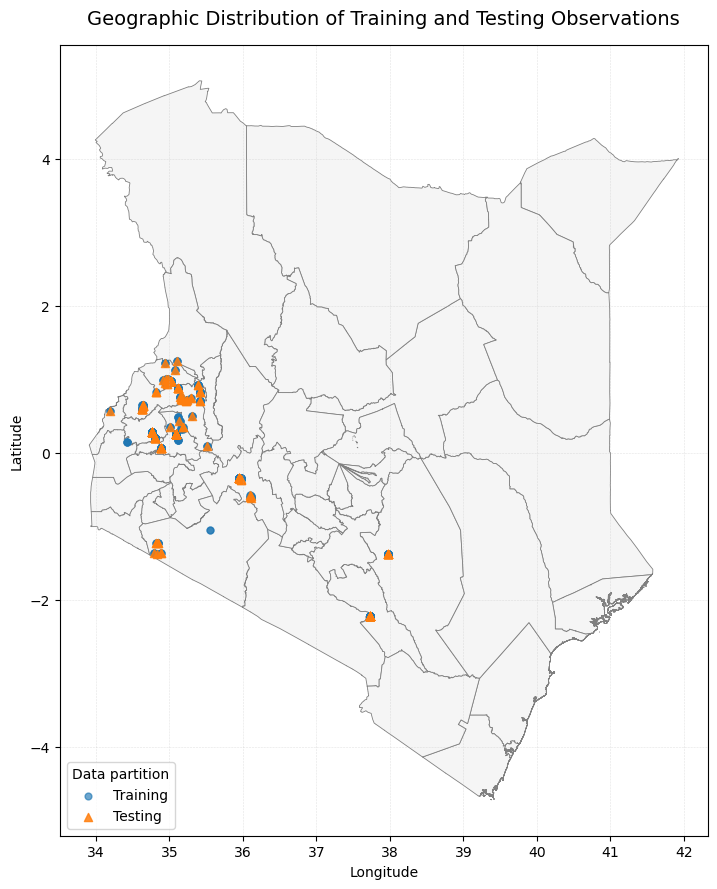

In [47]:
# Geographic distribution of the random 80:20 split

# Combine training and testing records
split_plot = pd.concat([
    geoai_train.assign(Partition="Training"),
    geoai_test.assign(Partition="Testing")
], ignore_index=True)

# Convert the modelling points to a GeoDataFrame
split_gdf = gpd.GeoDataFrame(
    split_plot,
    geometry=gpd.points_from_xy(
        split_plot["long2"],
        split_plot["lat2"]
    ),
    crs="EPSG:4326"
)

# Ensure county boundaries use the same CRS
kenya_map = kenya_adm1.to_crs("EPSG:4326")

# Plot
fig, ax = plt.subplots(figsize=(9, 9))

# Kenya county boundaries as the basemap
kenya_map.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="grey",
    linewidth=0.6
)

# Training points
split_gdf[
    split_gdf["Partition"] == "Training"
].plot(
    ax=ax,
    markersize=24,
    alpha=0.65,
    label="Training"
)

# Testing points
split_gdf[
    split_gdf["Partition"] == "Testing"
].plot(
    ax=ax,
    markersize=34,
    alpha=0.85,
    marker="^",
    label="Testing"
)

ax.set_title(
    "Geographic Distribution of Training and Testing Observations",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend(
    title="Data partition",
    frameon=True,
    loc="lower left"
)

ax.grid(
    linestyle="--",
    linewidth=0.4,
    alpha=0.35
)

plt.tight_layout()
plt.show()

**Interpretation:** Training and testing points occupy the same general geographic footprint. Because the split is random rather than spatial, the map is expected to show overlap between the two partitions. The figure therefore demonstrates geographic coverage of the split, not prediction at completely new sites.


## 6.5 Machine Learning Models and Evaluation Metrics

Five regression algorithms are compared:

- **Ridge Regression** as a regularised linear baseline;
- **Random Forest** for nonlinear relationships using bagged decision trees;
- **Extra Trees** for highly randomised tree ensembles;
- **Gradient Boosting** for sequential improvement of weak trees;
- **Histogram Gradient Boosting** as an efficient nonlinear boosting approach.

Performance is assessed using **R², RMSE and MAE**. The difference between training and testing R² is also reviewed as a simple overfitting diagnostic.


In [48]:
# Model definitions and metrics
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }

candidate_models = {
    "Ridge Regression": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=600,
        max_features=0.70,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=700,
        max_features=0.80,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=450,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=4,
        subsample=0.85,
        random_state=RANDOM_STATE,
        loss="huber",
    ),
    "Histogram Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=450,
        learning_rate=0.04,
        max_leaf_nodes=31,
        min_samples_leaf=15,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
}

def make_pipeline(model_name, model):
    if model_name == "Ridge Regression":
        prep = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])
    else:
        prep = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ])

    return Pipeline([
        ("prep", prep),
        ("model", model),
    ])

print("Candidate models:")
for model_name in candidate_models:
    print(" -", model_name)

Candidate models:
 - Ridge Regression
 - Random Forest
 - Extra Trees
 - Gradient Boosting
 - Histogram Gradient Boosting


**Explanation:** Five regression algorithms are compared so that the result is not dependent on a single modelling method. The candidate set includes a regularised linear model, bagged tree models and boosting models, allowing both simple and nonlinear relationships to be tested.


## 6.6 Comparative Model Performance

Each algorithm is fitted using each feature architecture. The same training and testing observations are used throughout the comparison. Cross-validation within the training data is used to assess stability, while the held-out testing data provide the final comparison of predictive performance.


In [49]:
# Fit all model / feature-set combinations
cv = KFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

model_results = []
fitted_models = {}

for feature_set_name, features in feature_sets.items():

    X_train = geoai_train[features]
    y_train = geoai_train["yield"]
    X_test = geoai_test[features]
    y_test = geoai_test["yield"]

    for model_name, base_model in candidate_models.items():

        pipe = make_pipeline(model_name, clone(base_model))

        cv_r2 = cross_val_score(
            pipe,
            X_train,
            y_train,
            scoring="r2",
            cv=cv,
            n_jobs=1,
        )

        pipe.fit(X_train, y_train)

        pred_train = pipe.predict(X_train)
        pred_test = pipe.predict(X_test)

        train_m = regression_metrics(y_train, pred_train)
        test_m = regression_metrics(y_test, pred_test)

        model_results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "n_features": len(features),
            "CV_R2_mean": np.mean(cv_r2),
            "Train_R2": train_m["R2"],
            "Test_R2": test_m["R2"],
            "Train_RMSE": train_m["RMSE"],
            "Test_RMSE": test_m["RMSE"],
            "Test_MAE": test_m["MAE"],
            "Generalization_gap_R2": train_m["R2"] - test_m["R2"],
        })

        fitted_models[(feature_set_name, model_name)] = pipe

results_df = (
    pd.DataFrame(model_results)
    .sort_values(["Test_R2", "CV_R2_mean"], ascending=[False, False])
    .reset_index(drop=True)
)

results_df.to_csv(
    OUTPUTS / "tables" / "cat2_all_model_results.csv",
    index=False
)

best_by_feature = (
    results_df
    .sort_values(["feature_set", "CV_R2_mean"], ascending=[True, False])
    .groupby("feature_set", as_index=False)
    .head(1)
    .sort_values("Test_R2", ascending=False)
    .reset_index(drop=True)
)

display(
    best_by_feature[
        [
            "feature_set", "model", "CV_R2_mean",
            "Train_R2", "Test_R2",
            "Train_RMSE", "Test_RMSE",
            "Generalization_gap_R2"
        ]
    ].round(3)
)

  File "C:\Users\L.Nturibi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\L.Nturibi\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\L.Nturibi\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\L.Nturibi\anaconda3

,feature_set,model,CV_R2_mean,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Generalization_gap_R2
0,N + P + AlphaEarth,Gradient Boosting,0.562,0.684,0.682,1328.534,1282.251,0.002
1,Full GeoAI,Gradient Boosting,0.564,0.687,0.662,1323.063,1321.742,0.025
2,N + P + Soil + Climate,Gradient Boosting,0.561,0.669,0.638,1361.201,1368.717,0.031
3,N + P + Climate,Gradient Boosting,0.558,0.643,0.632,1412.427,1379.135,0.011
4,N + P + Soil/Topography,Random Forest,0.544,0.680,0.618,1337.666,1404.932,0.062
5,AlphaEarth only,Random Forest,0.476,0.569,0.534,1552.700,1553.073,0.035
6,N + P,Random Forest,0.159,0.192,0.258,2125.382,1959.215,-0.066


**Interpretation:** The strongest architecture is **N + P + AlphaEarth with Gradient Boosting**, with **training R² = 0.684**, **testing R² = 0.682**, **CV R² = 0.562**, and **testing RMSE = 1,282 kg/ha**. The conventional N + P + soil + climate model reaches **testing R² = 0.638**, while N + P alone reaches only **0.258**. The lower CV R² shows that performance varies across folds, so the 0.682 test result should be interpreted together with the more conservative cross-validation result.


### 6.6.1 Training and Testing R²

The training and testing R² values show how much yield variation is explained by each feature architecture. The strongest model, N + P + AlphaEarth, has very similar training and testing R² values, indicating a small train-test performance gap under this validation design.


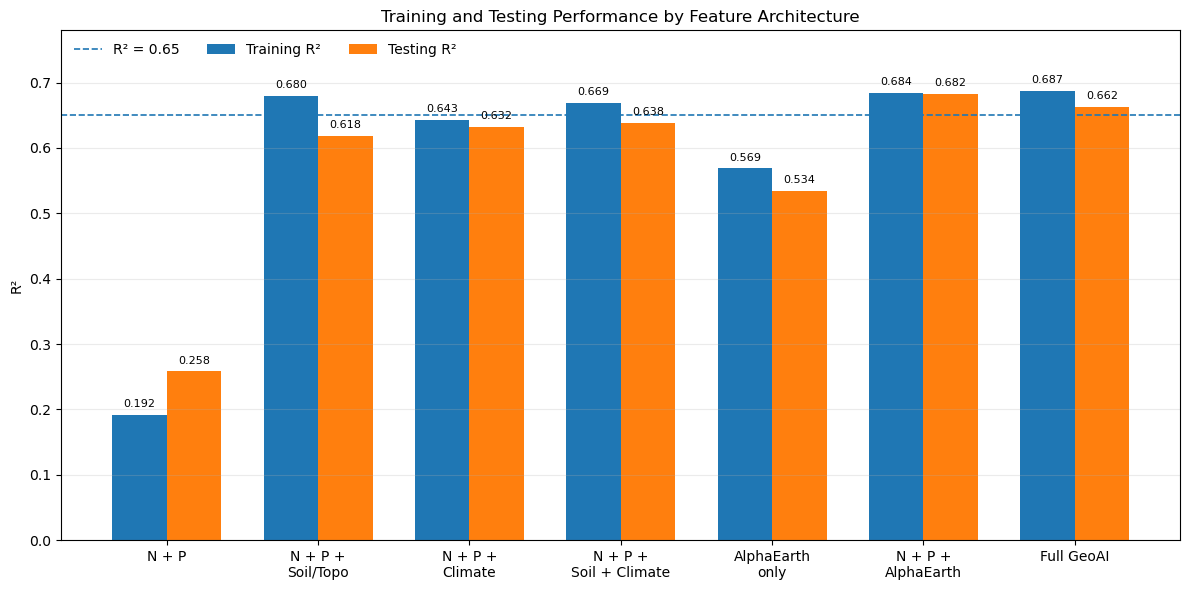

In [50]:
# Portable static performance figure
plot_df = best_by_feature.copy()

display_order = [
    "N + P",
    "N + P + Soil/Topography",
    "N + P + Climate",
    "N + P + Soil + Climate",
    "AlphaEarth only",
    "N + P + AlphaEarth",
    "Full GeoAI",
]

plot_df = (
    plot_df
    .set_index("feature_set")
    .loc[display_order]
    .reset_index()
)

labels = [
    "N + P",
    "N + P +\nSoil/Topo",
    "N + P +\nClimate",
    "N + P +\nSoil + Climate",
    "AlphaEarth\nonly",
    "N + P +\nAlphaEarth",
    "Full GeoAI",
]

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 6))
train_bars = ax.bar(
    x - width/2,
    plot_df["Train_R2"],
    width=width,
    label="Training R²"
)
test_bars = ax.bar(
    x + width/2,
    plot_df["Test_R2"],
    width=width,
    label="Testing R²"
)

ax.axhline(0.65, linestyle="--", linewidth=1.2, label="R² = 0.65") #goal was to get an accuracy of 65%
ax.set_title("Training and Testing Performance by Feature Architecture")
ax.set_ylabel("R²")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 0.78)
ax.legend(frameon=False, ncol=3, loc="upper left")
ax.grid(axis="y", alpha=0.25)

for bars in [train_bars, test_bars]:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            value + 0.012,
            f"{value:.3f}",
            ha="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

**Interpretation:** N + P alone is a weak predictor of yield variation, with **testing R² = 0.258**. Adding environmental information improves performance substantially. The best result is **N + P + AlphaEarth**, with training and testing R² values of **0.684 and 0.682**, showing a very small train-test gap under this split.


### 6.6.2 Best Feature Architecture

The held-out testing R² provides a direct comparison of the seven feature architectures. This figure identifies which information combination provides the strongest prediction on the testing data.


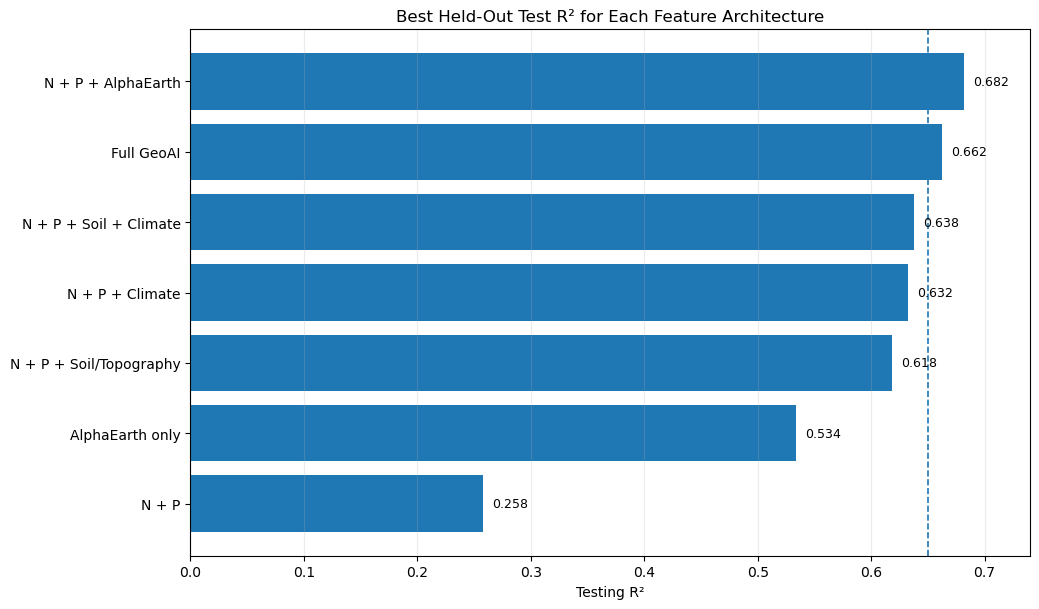

In [51]:
# Held-out testing R² by architecture
plot_df = best_by_feature.sort_values("Test_R2", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10.5, 6.2))
bars = ax.barh(plot_df["feature_set"], plot_df["Test_R2"])

ax.axvline(0.65, linestyle="--", linewidth=1.2) # 65% line
ax.set_title("Best Held-Out Test R² for Each Feature Architecture")
ax.set_xlabel("Testing R²")
ax.set_xlim(0, 0.74)
ax.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, plot_df["Test_R2"]):
    ax.text(
        value + 0.008,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Interpretation:** The two strongest testing results both include AlphaEarth. **N + P + AlphaEarth reaches R² = 0.682**, followed by **Full GeoAI at 0.662**. The simpler embedding-enhanced model also outperforms the conventional N + P + soil + climate architecture at **0.638**, showing that more predictors do not automatically produce a better model.


### 6.6.3 Prediction Error

RMSE expresses prediction error in the original yield units. The N + P + AlphaEarth architecture records the lowest testing RMSE, which supports the same ranking observed with testing R².


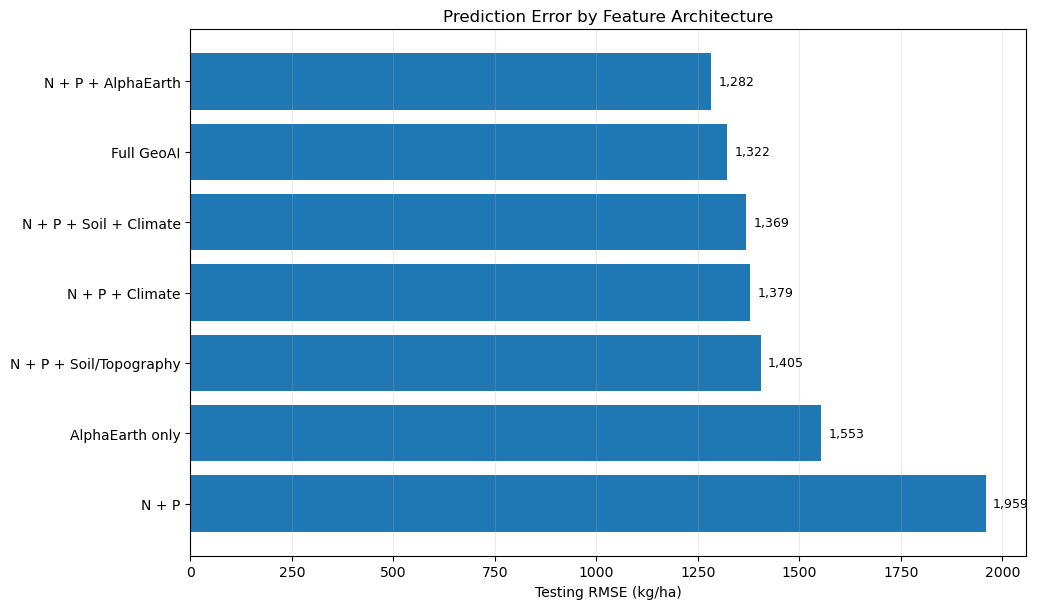

In [52]:
# Test RMSE by architecture
plot_df = best_by_feature.sort_values("Test_RMSE", ascending=False).copy()

fig, ax = plt.subplots(figsize=(10.5, 6.2))
bars = ax.barh(plot_df["feature_set"], plot_df["Test_RMSE"])

ax.set_title("Prediction Error by Feature Architecture")
ax.set_xlabel("Testing RMSE (kg/ha)")
ax.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, plot_df["Test_RMSE"]):
    ax.text(
        value + 18,
        bar.get_y() + bar.get_height()/2,
        f"{value:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Interpretation:** N + P + AlphaEarth has the lowest testing error, with **RMSE = 1,282 kg/ha**. Full GeoAI is next at about **1,322 kg/ha**, followed by the conventional soil and climate model at about **1,369 kg/ha**. The RMSE comparison supports the same conclusion as R²: the embedding-enhanced architecture gives the strongest predictive performance in this experiment.


# Objective 7: Quantify the Predictive Value of AlphaEarth Embeddings

## 7.1 Incremental Value of AlphaEarth

The feature comparison provides four main findings:

1. **AlphaEarth alone reaches R² = 0.534.** This shows that the embeddings contain useful environmental information even without explicit fertilizer rates.
2. **N + P + AlphaEarth reaches R² = 0.682**, compared with **0.258 for N + P alone**. This is an absolute improvement of **0.424 R²**.
3. **N + P + AlphaEarth also outperforms the conventional N + P + soil + climate model**, which reaches **R² = 0.638**. Testing RMSE decreases from about **1,369 kg/ha to 1,282 kg/ha**.
4. **Full GeoAI reaches R² = 0.662**, which is strong but slightly below N + P + AlphaEarth. This suggests that adding more predictors does not automatically improve prediction and that some information may be redundant.

These results support the conclusion that AlphaEarth embeddings provide complementary environmental information for maize yield prediction.


## 7.2 Results and Discussion by Objective

### Objective 1: Clean and structure the Long Rain trial data

The source trial records were cleaned while preserving row-level yield and fertilizer treatments. The final Long Rain analysis table contained **10,842 observations from 28 counties**.

### Objective 2: Validate spatial data quality

Coordinate validation identified records that required correction or quarantine before geospatial extraction. This reduced the risk of attaching environmental information from the wrong location.

### Objective 3: Conduct descriptive and diagnostic analysis

The exploratory analysis showed wide variation in yield across observations, years and counties. This supported the need to include environmental information in addition to fertilizer rates.

### Objective 4: Integrate climate, soil and topography

Climate, soil and topographic variables were successfully added to the trial observations while preserving the original treatment-level structure.

### Objective 5: Integrate AlphaEarth embeddings

AlphaEarth provided 64 learned embedding dimensions for recent trial years. A common subset of **1,036 observations** was created so that embedding and non-embedding models could be compared fairly.

### Objective 6: Compare machine learning performance

The fertilizer-only N + P model achieved a testing R² of **0.258**. Adding soil/topography increased testing R² to **0.618**, climate increased it to **0.632**, and the conventional N + P + soil + climate architecture reached **0.638**.

### Objective 7: Quantify the value of AlphaEarth

The best-performing architecture was **N + P + AlphaEarth**, using Gradient Boosting. It achieved **training R² = 0.684**, **testing R² = 0.682**, and **testing RMSE = 1,282 kg/ha**. AlphaEarth alone reached **R² = 0.534**, showing that the embeddings contain useful yield-related environmental information. Full GeoAI reached **R² = 0.662**, which remained strong but did not outperform the simpler N + P + AlphaEarth architecture.

Overall, the results show that environmental context improves prediction and that AlphaEarth embeddings provide useful additional information when combined with fertilizer inputs.


# Conclusion

This study developed a complete GeoAI workflow for maize yield prediction using Kenyan agronomic trial data, conventional geospatial variables and AlphaEarth satellite embeddings.

The results show that fertilizer rates alone are not sufficient to explain the observed yield variation. N + P produced a testing R² of **0.258**, while the conventional N + P + soil + climate model improved performance to **0.638**. The strongest architecture was **N + P + AlphaEarth**, where Gradient Boosting achieved **training R² = 0.684**, **testing R² = 0.682**, and **testing RMSE = 1,282 kg/ha**.

The main conclusion is that AlphaEarth embeddings provide useful environmental information that complements fertilizer inputs. The result is encouraging for GeoAI-based agronomic modelling, although wider spatial and temporal validation would be needed before applying the model operationally.


# Recommendations and Future Work

The current analysis provides a strong proof of concept. Future work should focus on the following areas:

1. **Test other Earth observation embeddings.** AlphaEarth should be compared with approaches such as Clay, Prithvi and TerraMind where suitable data are available.
2. **Investigate feature redundancy.** The Full GeoAI model did not outperform N + P + AlphaEarth, so future analysis should test whether some soil and climate information is already represented in the embeddings.
3. **Expand the common modelling sample.** More recent trial observations with reliable coordinates would strengthen the embedding comparison.
4. **Refine model optimisation.** Additional tuning and ensemble approaches can be tested after the preferred feature architecture is confirmed.
5. **Test wider generalisation.** Future work should evaluate performance across new sites, years and production environments.
6. **Move toward decision support.** Once model reliability is established, the workflow can be extended toward spatial fertilizer-response and recommendation products.


# References and Data Sources

- KALRO, CIAT and IITA maize trial data: internal long-term on-station trial dataset used for this project.
- GADM 4.1 Kenya administrative boundaries: https://gadm.org/data.html
- CHIRPS Daily rainfall in Google Earth Engine: `UCSB-CHG/CHIRPS/DAILY`.
- ERA5-Land Monthly Aggregated data in Google Earth Engine: `ECMWF/ERA5_LAND/MONTHLY_AGGR`.
- ISRIC SoilGrids soil property layers.
- SRTM elevation data in Google Earth Engine: `USGS/SRTMGL1_003`.
- Google and Google DeepMind Satellite Embedding V1 annual collection: `GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL`.
- Google Earth Engine documentation for geospatial extraction.
- scikit-learn documentation for machine learning, cross-validation and evaluation.

***The agronomic trial dataset is internal, awaiting validation trials.It is therefore not redistribtributed in this submission.**